In [1]:
import os, re
import numpy as np
import scanpy as sc
from os.path import join
import pandas as pd

import sys
import scipy.io as sio
import scipy.sparse as sps
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from spamosaic.framework import SpaMosaic
import spamosaic.utils as utls
from spamosaic.preprocessing import RNA_preprocess, ADT_preprocess, Epigenome_preprocess, harmony

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8' 

In [2]:
data_dir = '../../../data/processed/MB-5M'

ad_mult_rna1 = sc.read_h5ad(join(data_dir, 'S1/ad_rna.h5ad'))
ad_mult_k27me3 = sc.read_h5ad(join(data_dir, 'S1/ad_h3k27me3.h5ad'))

ad_mult_rna2 = sc.read_h5ad(join(data_dir, 'S2/ad_rna.h5ad'))
ad_mult_k4me3 = sc.read_h5ad(join(data_dir, 'S2/ad_h3k4me3.h5ad'))

ad_mult_rna3 = sc.read_h5ad(join(data_dir, 'S3/ad_rna.h5ad'))
ad_mult_k27ac = sc.read_h5ad(join(data_dir, 'S3/ad_h3k27ac.h5ad'))

ad_mult_rna4 = sc.read_h5ad(join(data_dir, 'S4/ad_rna.h5ad'))
ad_mult_atac = sc.read_h5ad(join(data_dir, 'S4/ad_atac.h5ad'))

input_dict = { 
    'rna':       [ad_mult_rna1,   ad_mult_rna2, ad_mult_rna3,  ad_mult_rna4],
    'h3k27me3':  [ad_mult_k27me3, None,         None,          None],
    'h3k4me3':   [None,           ad_mult_k4me3,None,          None],
    'h3k27ac':   [None,           None,         ad_mult_k27ac, None],
    'atac':      [None,           None,         None,          ad_mult_atac]
}

input_key = 'dimred_bc'
batch_key = 'src'

In [3]:
Epigenome_preprocess(input_dict['h3k27me3'], batch_corr=True, n_peak=50000, batch_key=batch_key, key=input_key, return_hvf=False)
Epigenome_preprocess(input_dict['h3k4me3'], batch_corr=True, n_peak=50000, batch_key=batch_key, key=input_key, return_hvf=False)
Epigenome_preprocess(input_dict['h3k27ac'], batch_corr=True, n_peak=50000, batch_key=batch_key, key=input_key, return_hvf=False)
Epigenome_preprocess(input_dict['atac'], batch_corr=True, n_peak=50000, batch_key=batch_key, key=input_key, return_hvf=False)
RNA_preprocess(input_dict['rna'], batch_corr=True, n_hvg=10000, batch_key=batch_key, key=input_key)

Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
Reach convergence after 3 iteration(s).


In [4]:
model = SpaMosaic(
    modBatch_dict=input_dict, input_key=input_key,
    batch_key=batch_key, 
    intra_knns=10, inter_knn_base=10, w_g=0.8,
    seed=1234, 
    device='cuda:0'
)

model.train(net='wlgcn', lr=0.01, T=0.01, n_epochs=100)

batch0: ['rna', 'h3k27me3']
batch1: ['rna', 'h3k4me3']
batch2: ['rna', 'h3k27ac']
batch3: ['rna', 'atac']
------Calculating spatial graph...
The graph contains 97520 edges, 9752 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 95480 edges, 9548 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 93700 edges, 9370 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 92150 edges, 9215 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 97520 edges, 9752 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 95480 edges, 9548 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 93700 edges, 9370 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 92150 edges, 9

100%|███████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.21it/s]


In [5]:
ad_embs = model.infer_emb(input_dict, emb_key='emb', final_latent_key='merged_emb')
ad_mosaic = sc.concat(ad_embs)
ad_mosaic = utls.get_umap(ad_mosaic, use_reps=['merged_emb'])

ad_mosaic = utls.clustering(ad_mosaic, 15, 'merged_emb', algo='mclust', key='mclust')
utls.split_adata_ob(ad_embs, ad_mosaic, ob='obs', key='mclust')

/home/yanxh/anaconda3/envs/spamosaic-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.0
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


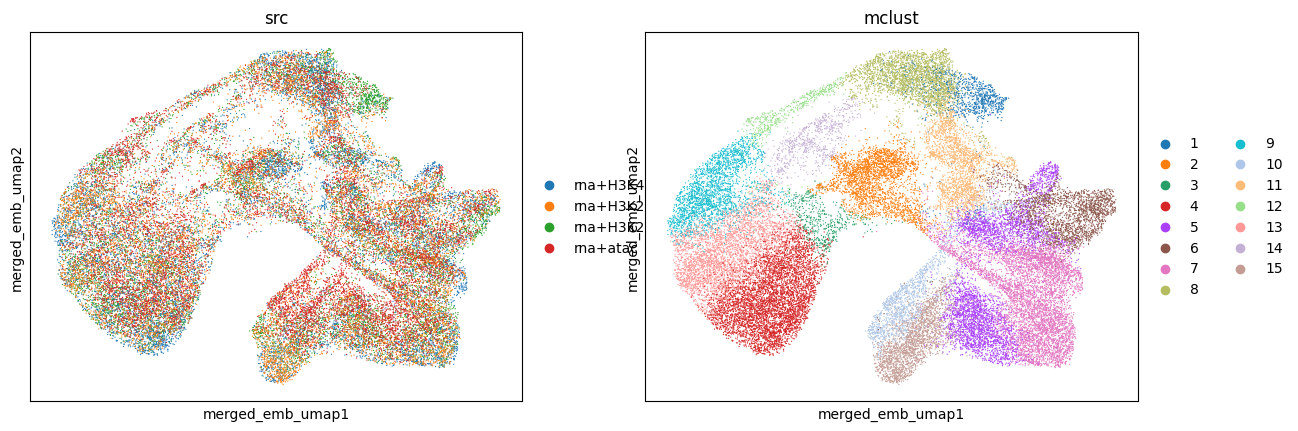

In [6]:
utls.plot_basis(ad_mosaic, 'merged_emb_umap', [batch_key, 'mclust'])

In [7]:
# make the color of clusters consistent across sections
def unify_colors(ads, ad_ref, color):
    cat2color = dict(zip(ad_ref.obs[color].cat.categories, ad_ref.uns[f'{color}_colors']))
    for ad in ads:
        ad.obs[color] = ad.obs[color].astype('category')
        ad.uns[f'{color}_colors'] = [ 
            cat2color.get(cat, '#000000')
            for cat in ad.obs[color].cat.categories
        ]

unify_colors(ad_embs, ad_mosaic, 'mclust')

In [10]:
utls.flip_axis(ad_embs, axis=0)
utls.flip_axis(ad_embs, axis=1)

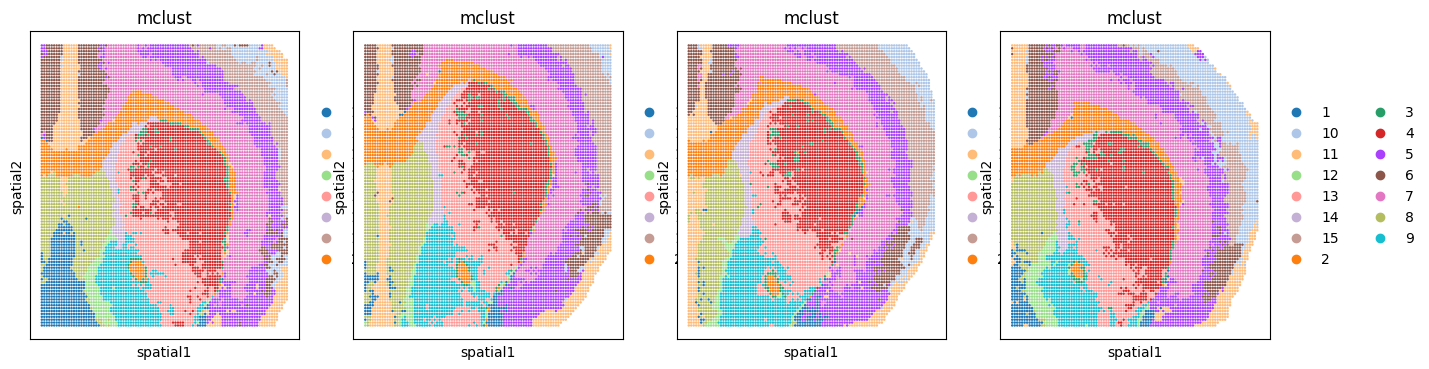

In [11]:
_, axes = plt.subplots(1, len(ad_embs), figsize=(4*len(ad_embs), 4))
for i,adx in enumerate(ad_embs):
    utls.plot_basis(adx, 'spatial', 'mclust', ax=axes[i], show=False)

plt.show()

In [9]:
fig_dir = f'../../../results/embeddings/SpaMosaic/MB-5M'
os.makedirs(fig_dir, exist_ok=True)

df = pd.DataFrame(ad_mosaic.obsm['merged_emb'], index=ad_mosaic.obs_names)
df.to_csv(join(fig_dir, 'df_emb.csv'))

### Imputation

In [21]:
def load_gam(_dir):
    bc = pd.read_csv(join(_dir, 'barcode.csv'))['x'].to_list()
    feat = pd.read_csv(join(_dir, 'feats.csv'))['x'].to_list()
    mat = sps.csr_matrix(sio.mmread(join(_dir, 'mat.mtx')).T)
    ad = sc.AnnData(mat)
    ad.obs_names = [x.replace('P21_', 'rna+').replace('#', '-')[:-2] for x in bc]
    ad.var_names = feat
    
    return ad

In [75]:
gsm_dir = '../../../data/processed/MB-5M/GSM'

ad_k27me3_gam = load_gam(join(gsm_dir, 'H3K27me3'))
ad_k27ac_gam = load_gam(join(gsm_dir, 'H3K27ac'))
ad_k4me3_gam = load_gam(join(gsm_dir, 'H3K4me3'))
ad_atac_gam = load_gam(join(gsm_dir, 'ATAC'))
ad_atac_gam.obs_names = ['rna+atac-' + x.split('-')[1] for x in ad_atac_gam.obs_names]

In [76]:
ad_k27me3_gam = ad_k27me3_gam[ad_mult_rna1.obs_names].copy()
ad_k4me3_gam = ad_k4me3_gam[ad_mult_rna2.obs_names].copy()
ad_k27ac_gam = ad_k27ac_gam[ad_mult_rna3.obs_names].copy()
ad_atac_gam = ad_atac_gam[ad_mult_rna4.obs_names].copy()

ad_k27me3_gam.obsm['emb'] = ad_mult_k27me3.obsm['emb'].copy()
ad_k4me3_gam.obsm['emb'] = ad_mult_k4me3.obsm['emb'].copy()
ad_k27ac_gam.obsm['emb'] = ad_mult_k27ac.obsm['emb'].copy()
ad_atac_gam.obsm['emb'] = ad_mult_atac.obsm['emb'].copy()

ad_k27me3_gam.obs['mclust'] = ad_mult_rna1.obs['mclust'].copy()
ad_k4me3_gam.obs['mclust'] = ad_mult_rna2.obs['mclust'].copy()
ad_k27ac_gam.obs['mclust'] = ad_mult_rna3.obs['mclust'].copy()
ad_atac_gam.obs['mclust'] = ad_mult_rna4.obs['mclust'].copy()

In [85]:
shared_gene = ad_mult_rna1.var_names
for adx in [ad_mult_rna2, ad_mult_rna3, ad_mult_rna4]:
    shared_gene = np.intersect1d(adx.var_names, shared_gene)
ad_mult_rna1 = ad_mult_rna1[:, shared_gene].copy()
ad_mult_rna2 = ad_mult_rna2[:, shared_gene].copy()
ad_mult_rna3 = ad_mult_rna3[:, shared_gene].copy()
ad_mult_rna4 = ad_mult_rna4[:, shared_gene].copy()

imp_input_dict = { 
    'rna':       [ad_mult_rna1,   ad_mult_rna2, ad_mult_rna3,  ad_mult_rna4],
    'h3k27me3':  [ad_k27me3_gam, None,         None,          None],
    'h3k4me3':   [None,           ad_k4me3_gam,None,          None],
    'h3k27ac':   [None,           None,         ad_k27ac_gam, None],
    'atac':      [None,           None,         None,          ad_atac_gam]
}

In [89]:
for k in imp_input_dict.keys():
    for bi in range(len(imp_input_dict[k])):
        if imp_input_dict[k][bi] is not None:
            imp_input_dict[k][bi].layers['counts'] = sps.csr_matrix(imp_input_dict[k][bi].X)

In [90]:
imputed_featureDict = model.impute(imp_input_dict, emb_key='emb', layer_key='counts', imp_knn=10)

impute h3k4me3-counts for batch-1
impute h3k27ac-counts for batch-1
impute atac-counts for batch-1
impute atac-counts for batch-2
impute h3k27me3-counts for batch-2
impute h3k27ac-counts for batch-2
impute h3k4me3-counts for batch-3
impute h3k27me3-counts for batch-3
impute atac-counts for batch-3
impute h3k4me3-counts for batch-4
impute h3k27me3-counts for batch-4
impute h3k27ac-counts for batch-4


In [92]:
def to_adx(obs, X, features):
    ad_imp_gam = sc.AnnData(sps.csr_matrix(X), obs=obs.copy())
    ad_imp_gam.var_names = list(features)
    return ad_imp_gam

In [93]:
utls.split_adata_ob([ad_mult_rna1, ad_mult_rna2, ad_mult_rna3, ad_mult_rna4], ad_mosaic, ob='obs', key='mclust')

In [94]:
ad2_imp_k27me3_gam = to_adx(ad_mult_rna2.obs, imputed_featureDict['h3k27me3'][1], ad_k27me3_gam.var_names)
ad3_imp_k27me3_gam = to_adx(ad_mult_rna3.obs, imputed_featureDict['h3k27me3'][2], ad_k27me3_gam.var_names)
ad4_imp_k27me3_gam = to_adx(ad_mult_rna4.obs, imputed_featureDict['h3k27me3'][3], ad_k27me3_gam.var_names)

ad1_imp_k4me3_gam = to_adx(ad_mult_rna1.obs, imputed_featureDict['h3k4me3'][0], ad_k4me3_gam.var_names)
ad3_imp_k4me3_gam = to_adx(ad_mult_rna3.obs, imputed_featureDict['h3k4me3'][2], ad_k4me3_gam.var_names)
ad4_imp_k4me3_gam = to_adx(ad_mult_rna4.obs, imputed_featureDict['h3k4me3'][3], ad_k4me3_gam.var_names)

ad1_imp_k27ac_gam = to_adx(ad_mult_rna1.obs, imputed_featureDict['h3k27ac'][0], ad_k27ac_gam.var_names)
ad2_imp_k27ac_gam = to_adx(ad_mult_rna2.obs, imputed_featureDict['h3k27ac'][1], ad_k27ac_gam.var_names)
ad4_imp_k27ac_gam = to_adx(ad_mult_rna4.obs, imputed_featureDict['h3k27ac'][3], ad_k27ac_gam.var_names)

ad1_imp_atac_gam = to_adx(ad_mult_rna1.obs, imputed_featureDict['atac'][0], ad_atac_gam.var_names)
ad2_imp_atac_gam = to_adx(ad_mult_rna2.obs, imputed_featureDict['atac'][1], ad_atac_gam.var_names)
ad3_imp_atac_gam = to_adx(ad_mult_rna3.obs, imputed_featureDict['atac'][2], ad_atac_gam.var_names)

In [95]:
ad2_imp_k27me3_gam.X.max(), np.log1p(ad2_imp_k27me3_gam.X).max()

(186.988, 5.236378131005507)

In [96]:
ad_k27me3_gam.X.max(), np.log1p(ad_k27me3_gam.X).max()

(402.534, 6.000260746861464)

In [99]:
def get_DEG(adx, key='mclust', norm=True):
    if 'rank_genes_groups' not in adx.uns:
        if norm:
            sc.pp.normalize_total(adx, target_sum=1e4)
        sc.pp.log1p(adx)
        sc.tl.rank_genes_groups(adx, key, method="wilcoxon")

In [103]:
for adx in [ad_mult_rna1, ad_mult_rna2, ad_mult_rna3, ad_mult_rna4]:
    get_DEG(adx, norm=True)

In [100]:
for adx in [ad1_imp_k4me3_gam, ad1_imp_k27ac_gam, ad1_imp_atac_gam, ad2_imp_k27me3_gam, ad2_imp_k27ac_gam, ad2_imp_atac_gam, 
            ad3_imp_k27me3_gam, ad3_imp_k4me3_gam, ad3_imp_atac_gam, ad4_imp_k27me3_gam, ad4_imp_k4me3_gam, ad4_imp_k27ac_gam]:  # log-normed
    # sc.tl.rank_genes_groups(adx, "mclust", method="wilcoxon")
    get_DEG(adx, norm=False)

In [101]:
for adx in [ad_k27me3_gam, ad_k4me3_gam, ad_k27ac_gam, ad_atac_gam]:
    get_DEG(adx, norm=False)

In [102]:
def scatter_plot_impGAM_Scpy(df_rna, df_gam, adj_pval_thr=0.1, logfc_cutoff=0.1, ax=None, s=40):
    df_rna_new = df_rna.loc[df_rna.pval_adj<=adj_pval_thr].copy()
    df_gam_new = df_gam.loc[df_gam.pval_adj<=adj_pval_thr].copy()
    df_rna_new = df_rna_new.loc[df_rna_new.logfc.abs() > logfc_cutoff].copy()
    df_gam_new = df_gam_new.loc[df_gam_new.logfc.abs() > logfc_cutoff].copy()
    
    shared_gene = df_rna_new.index.intersection(df_gam_new.index)
    df_rna_new = df_rna_new.loc[shared_gene].copy()
    df_gam_new = df_gam_new.loc[shared_gene].copy()
    # print(len(shared_gene))

    x = df_rna_new.loc[shared_gene, 'logfc']
    y = df_gam_new.loc[shared_gene, 'logfc']
    if ax is None:
        plt.scatter(x, y, s=s)
        ax = plt.gca()
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        plt.show()
    else:
        ax.scatter(x, y, s=s)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
    return x, y

def get_clust_marker(ad, clust):
    rank_names = ad.uns['rank_genes_groups']['names']
    rank_logfc = ad.uns['rank_genes_groups']['logfoldchanges']
    rank_pval  = ad.uns['rank_genes_groups']['pvals']
    rank_pval_adj  = ad.uns['rank_genes_groups']['pvals_adj']
    
    df_rank_scpy = pd.DataFrame(rank_logfc[clust].reshape(-1, 1), index=rank_names[clust], columns=['logfc'])
    df_rank_scpy['pval'] = rank_pval[clust]
    df_rank_scpy['pval_adj'] = rank_pval_adj[clust]
    return df_rank_scpy

======> 1


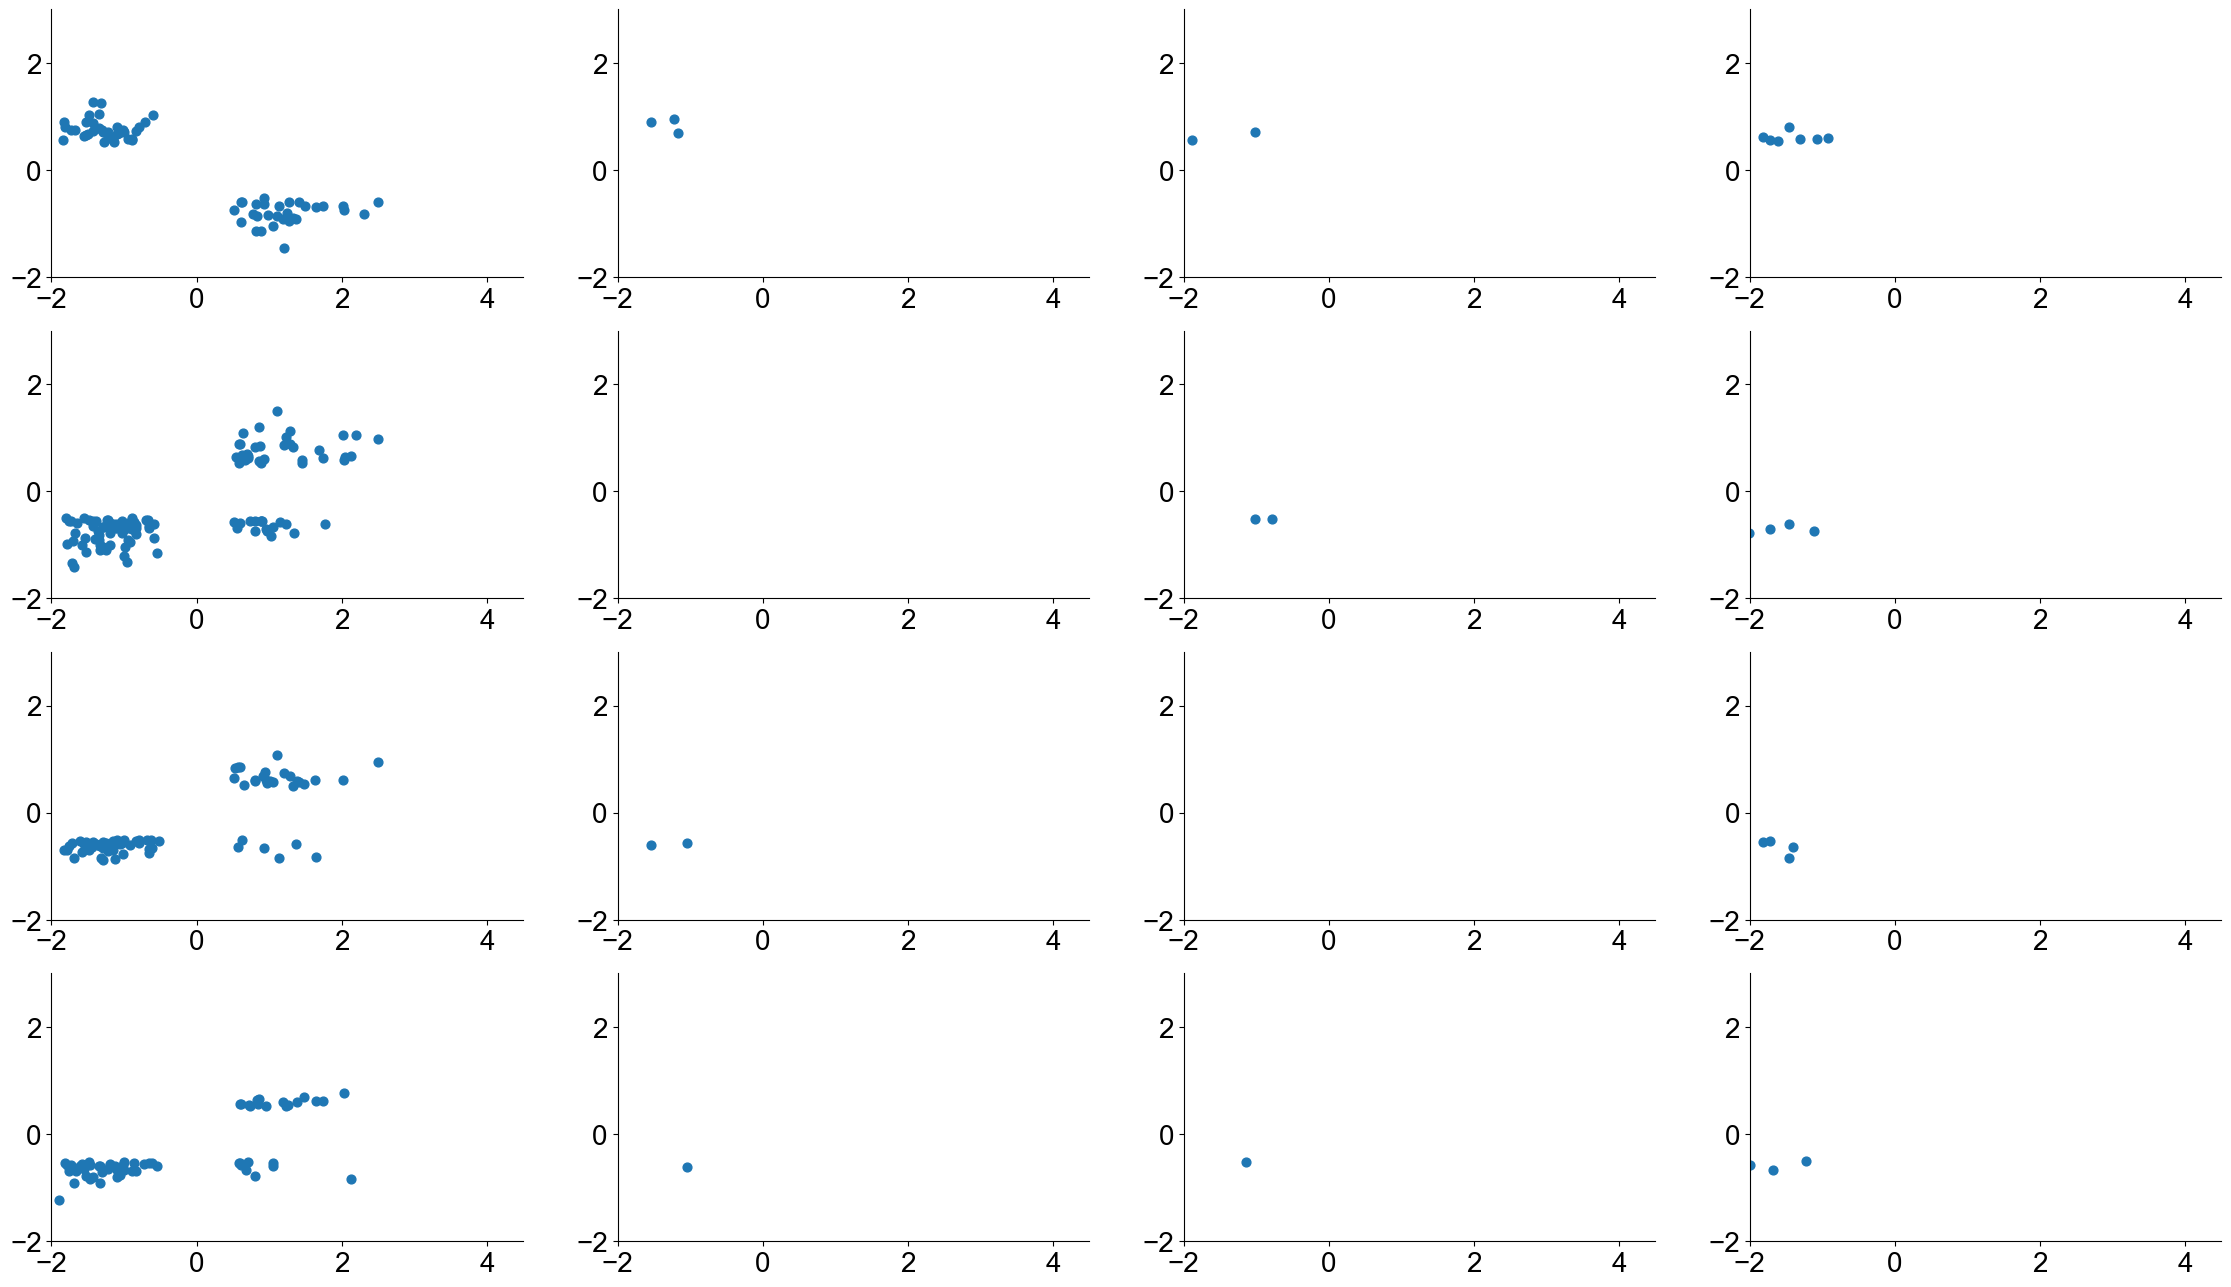

======> 2


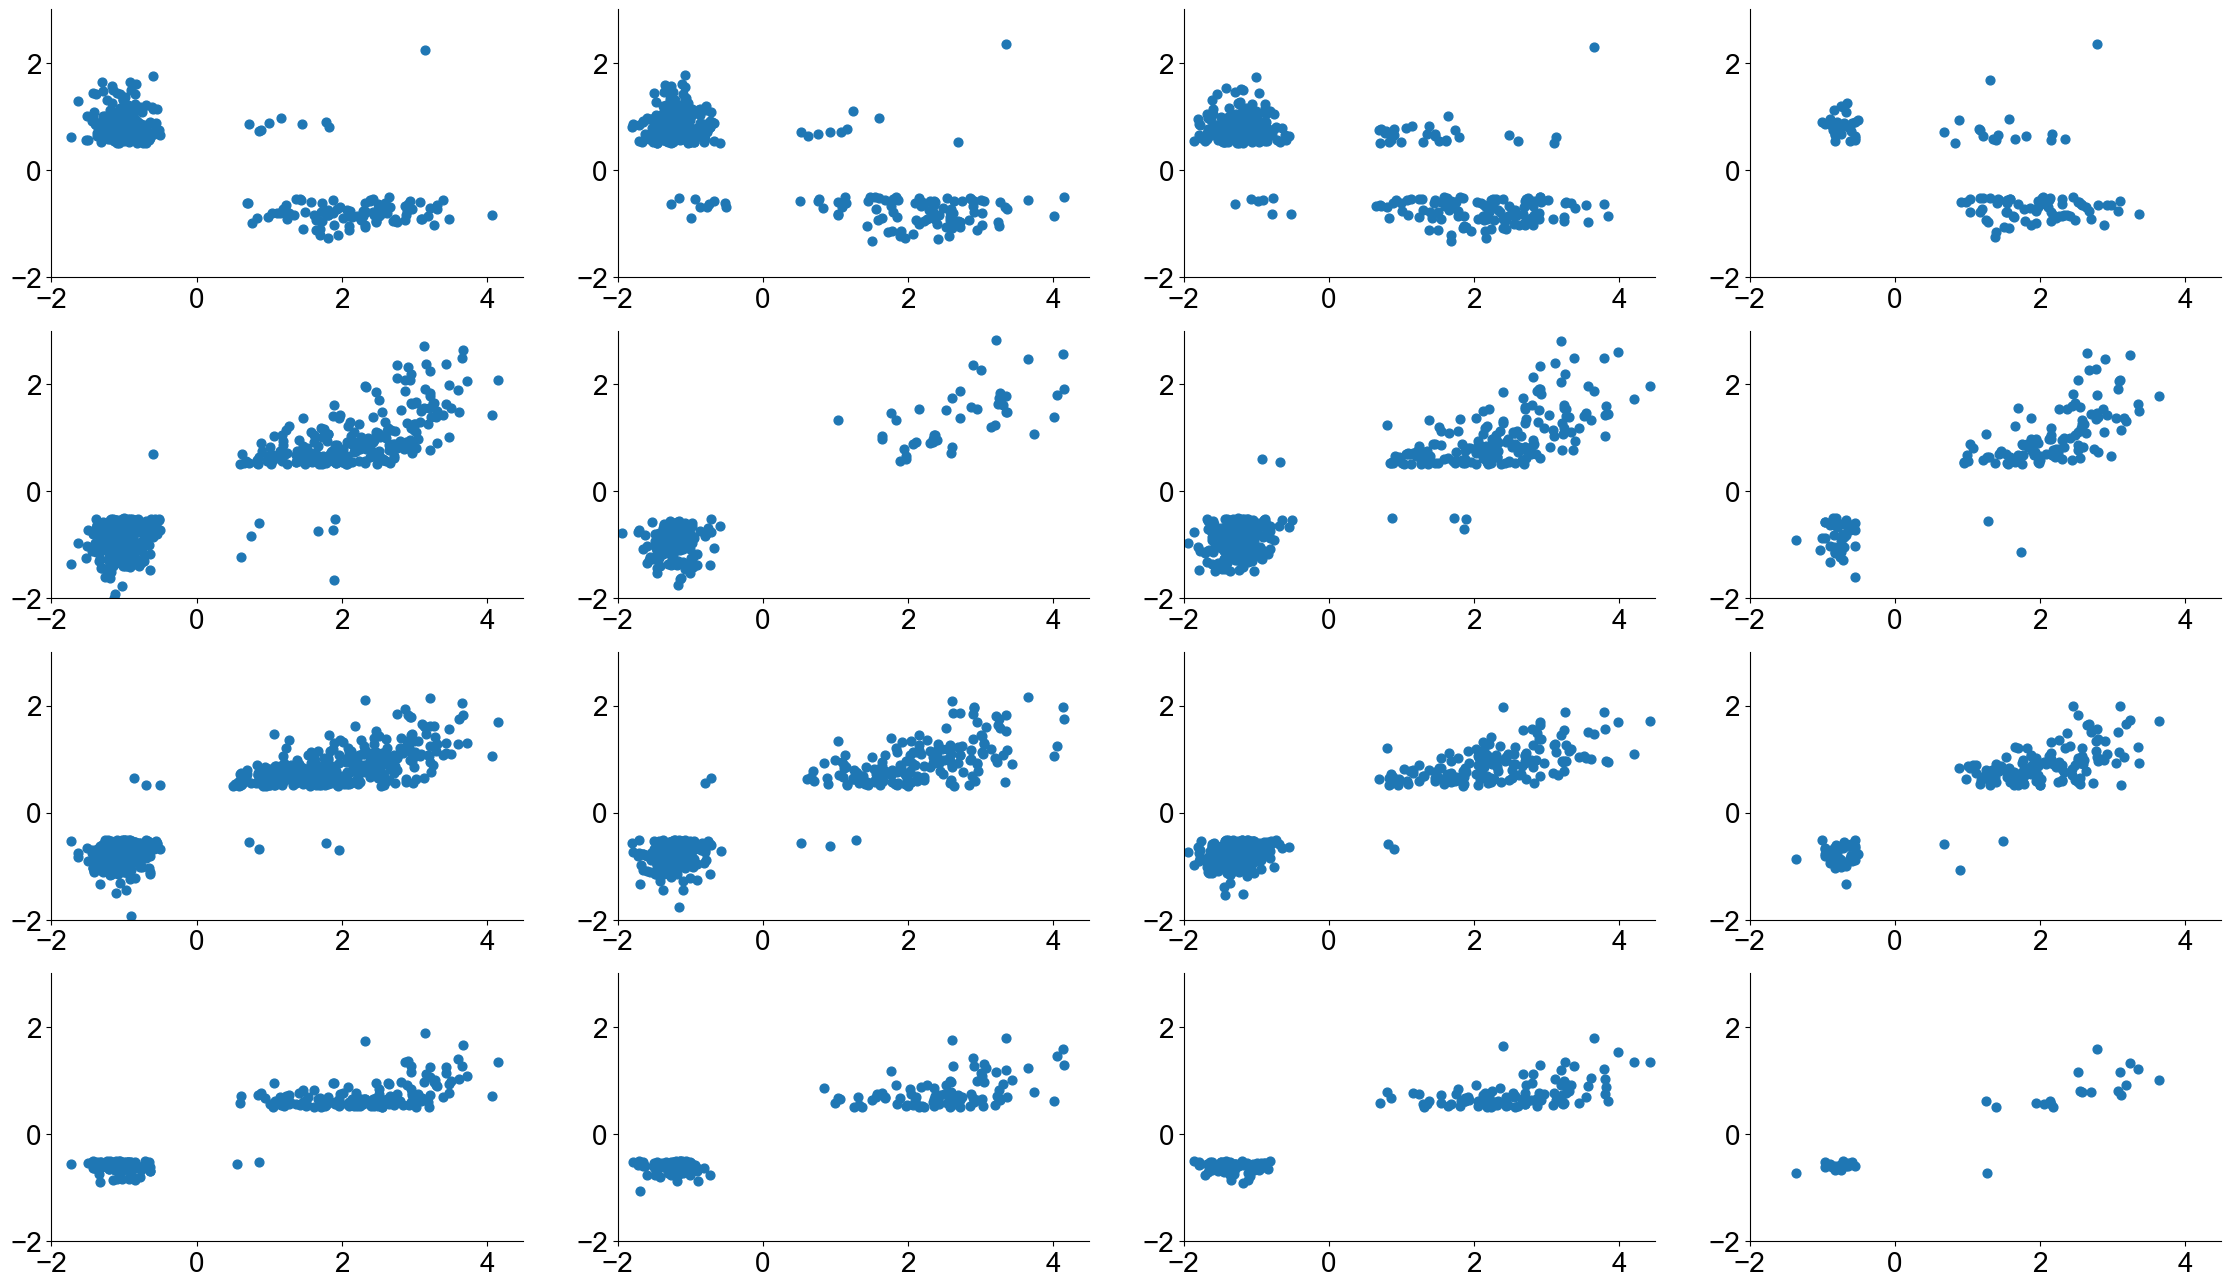

======> 3


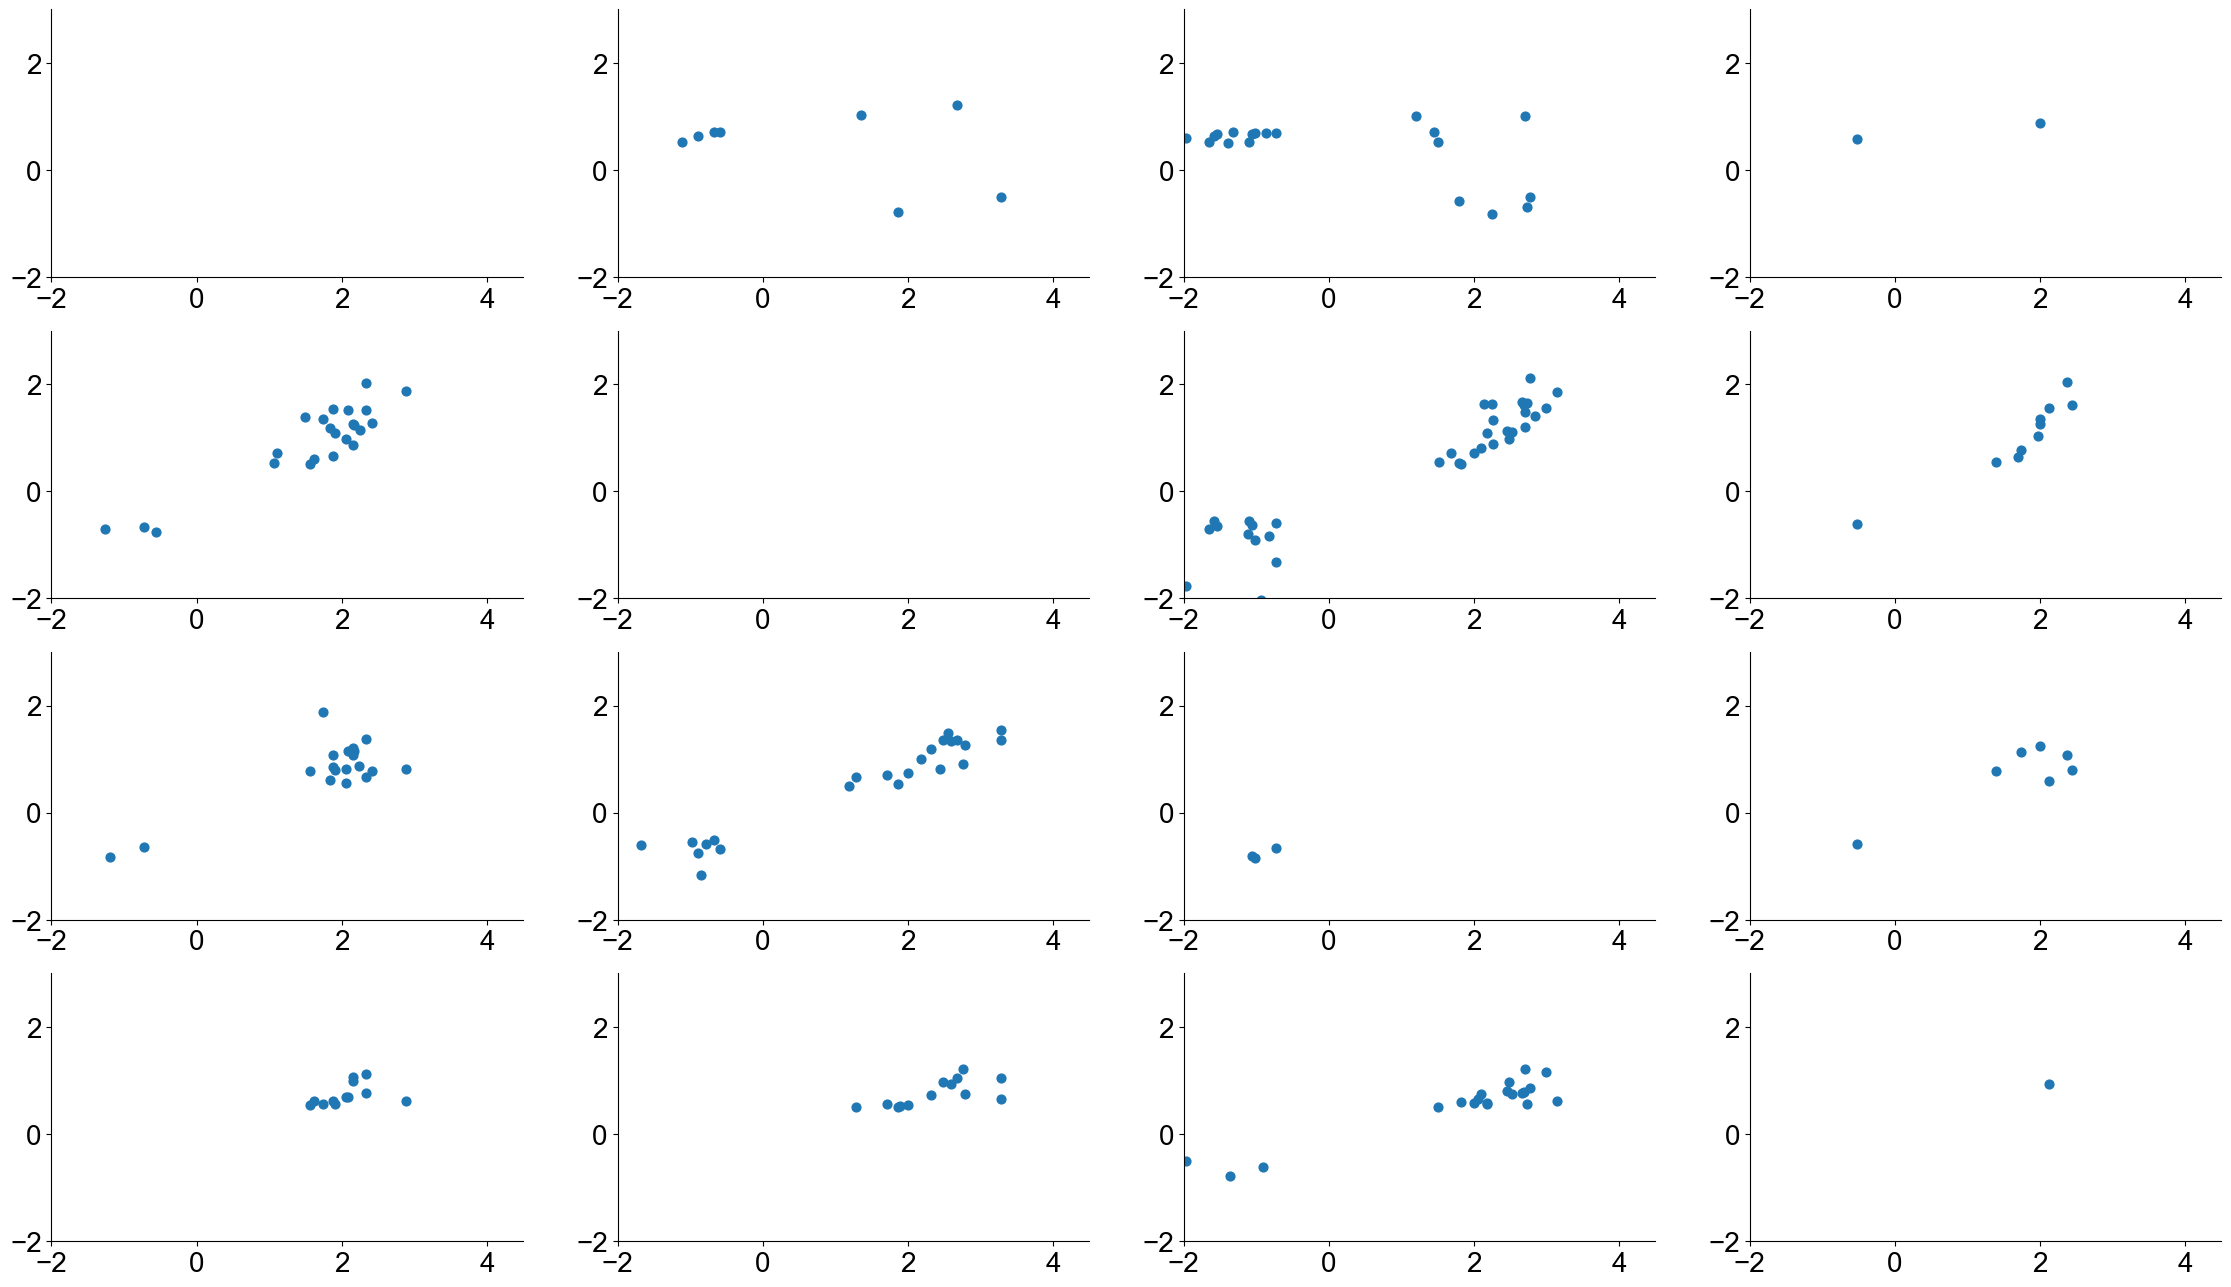

======> 4


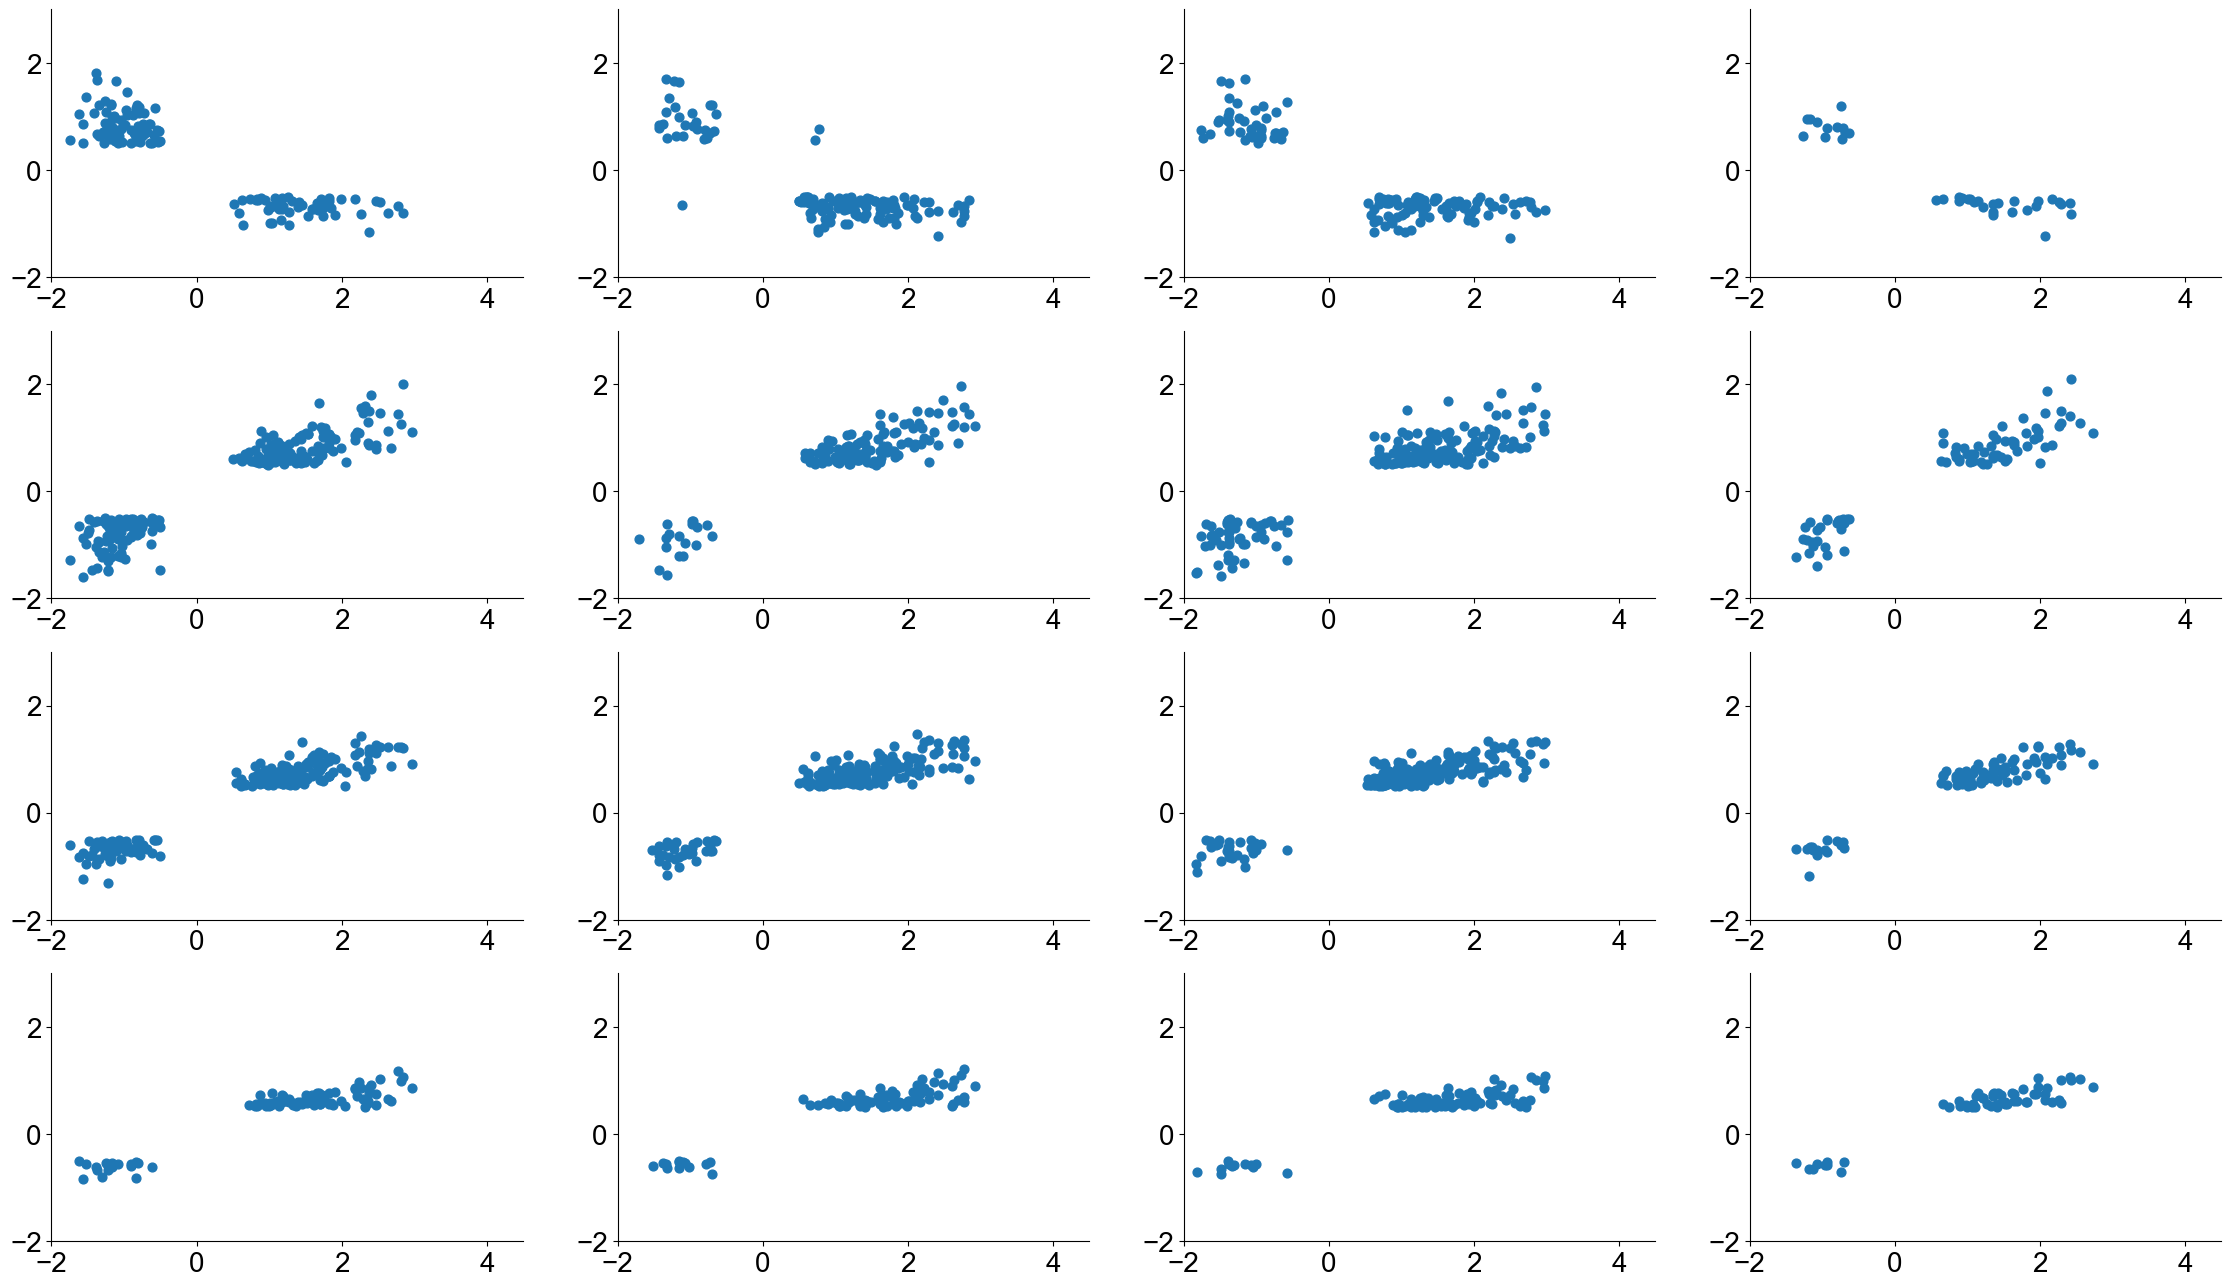

======> 5


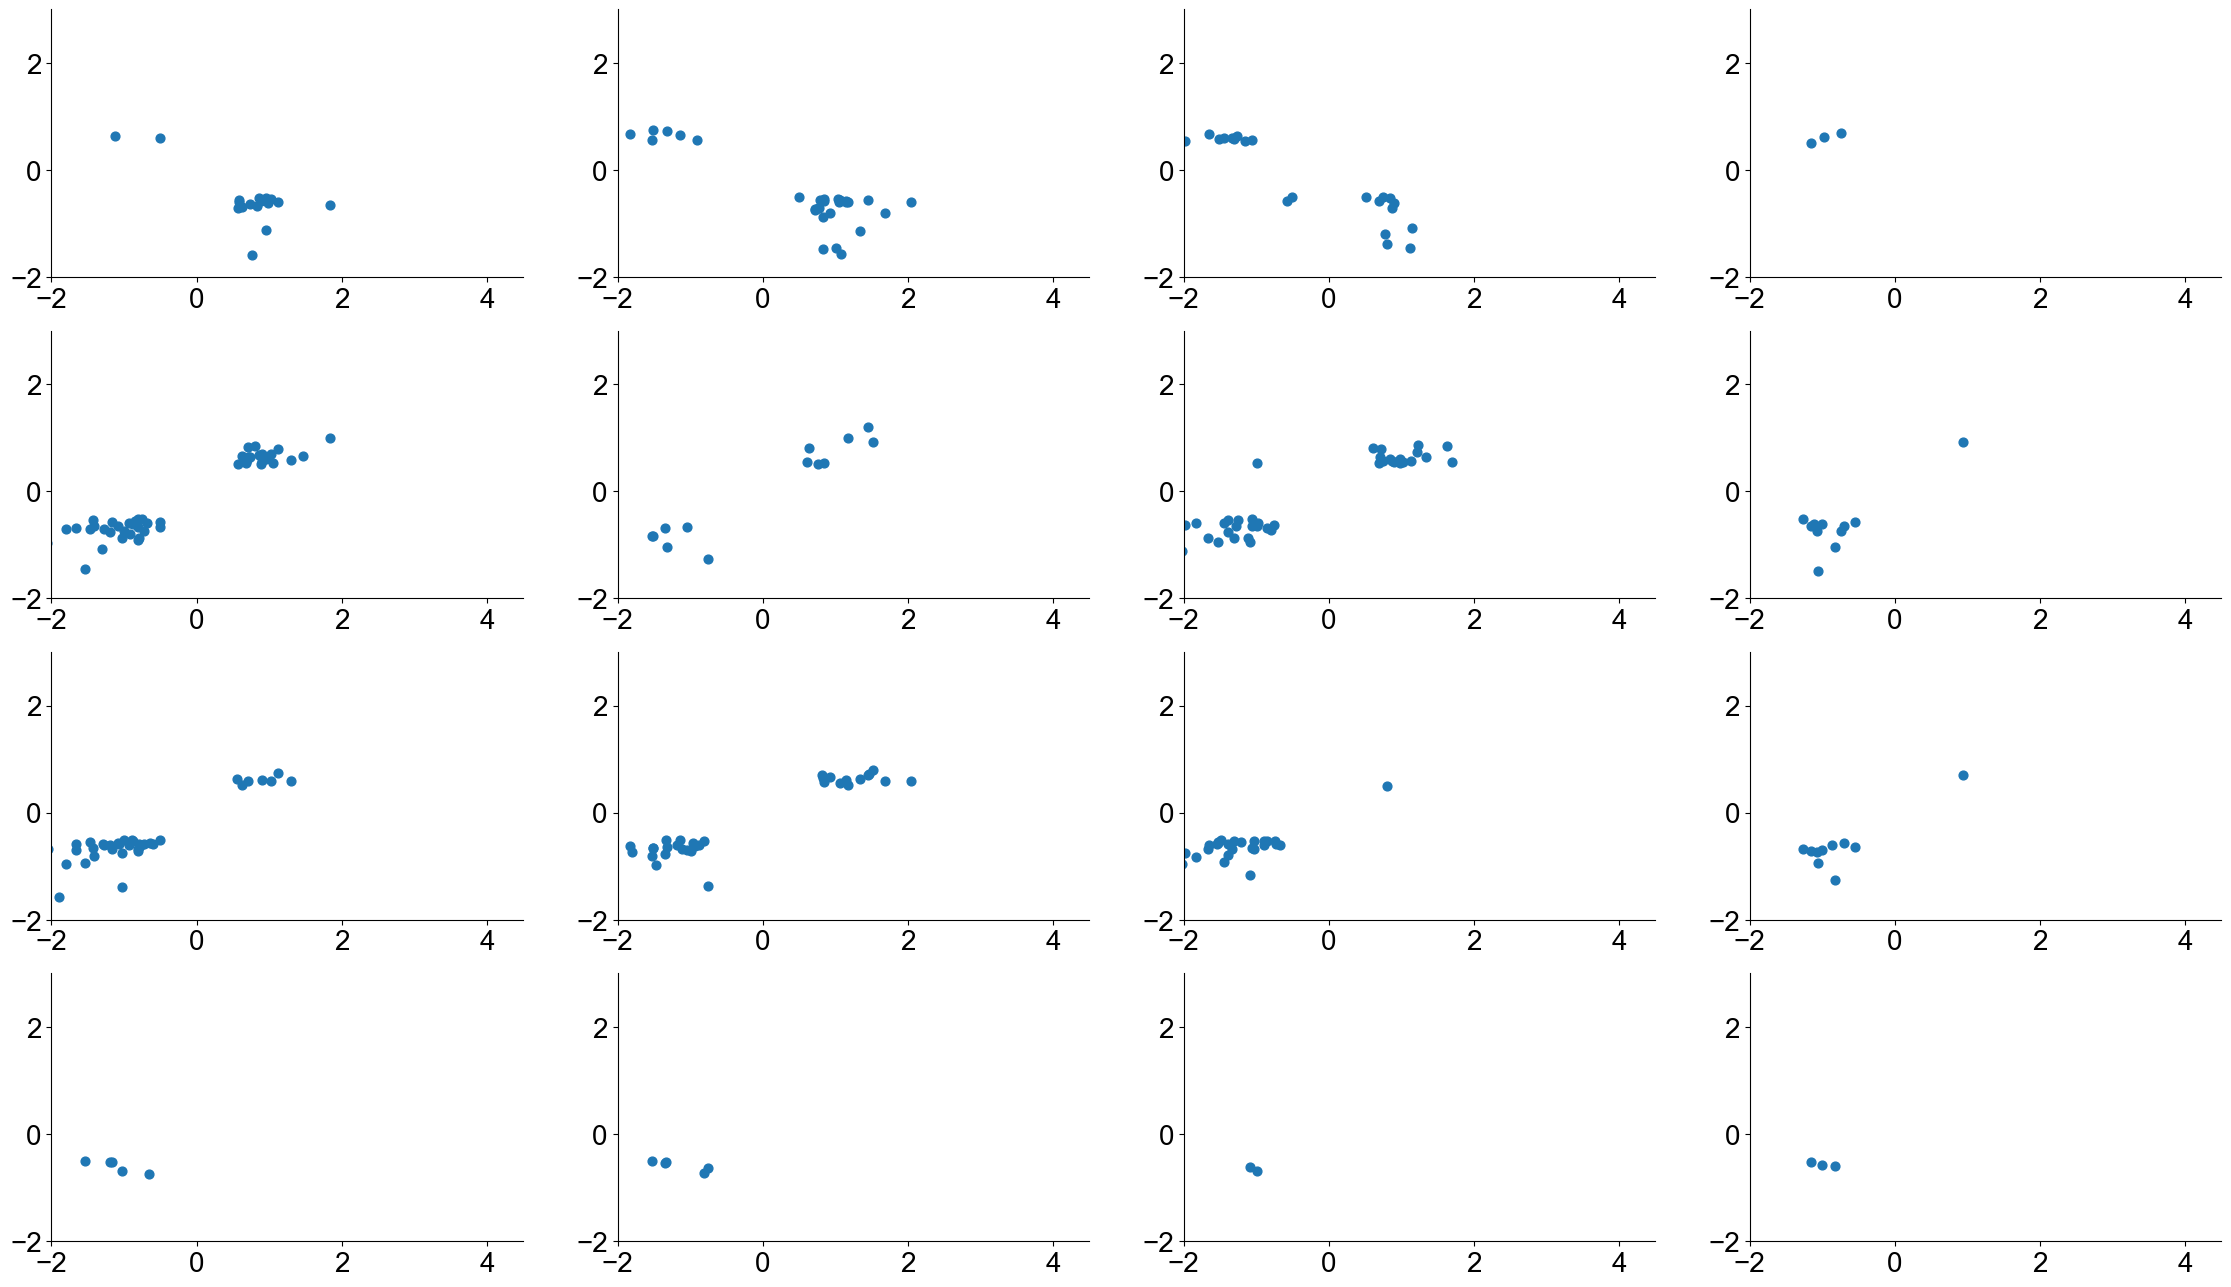

======> 6


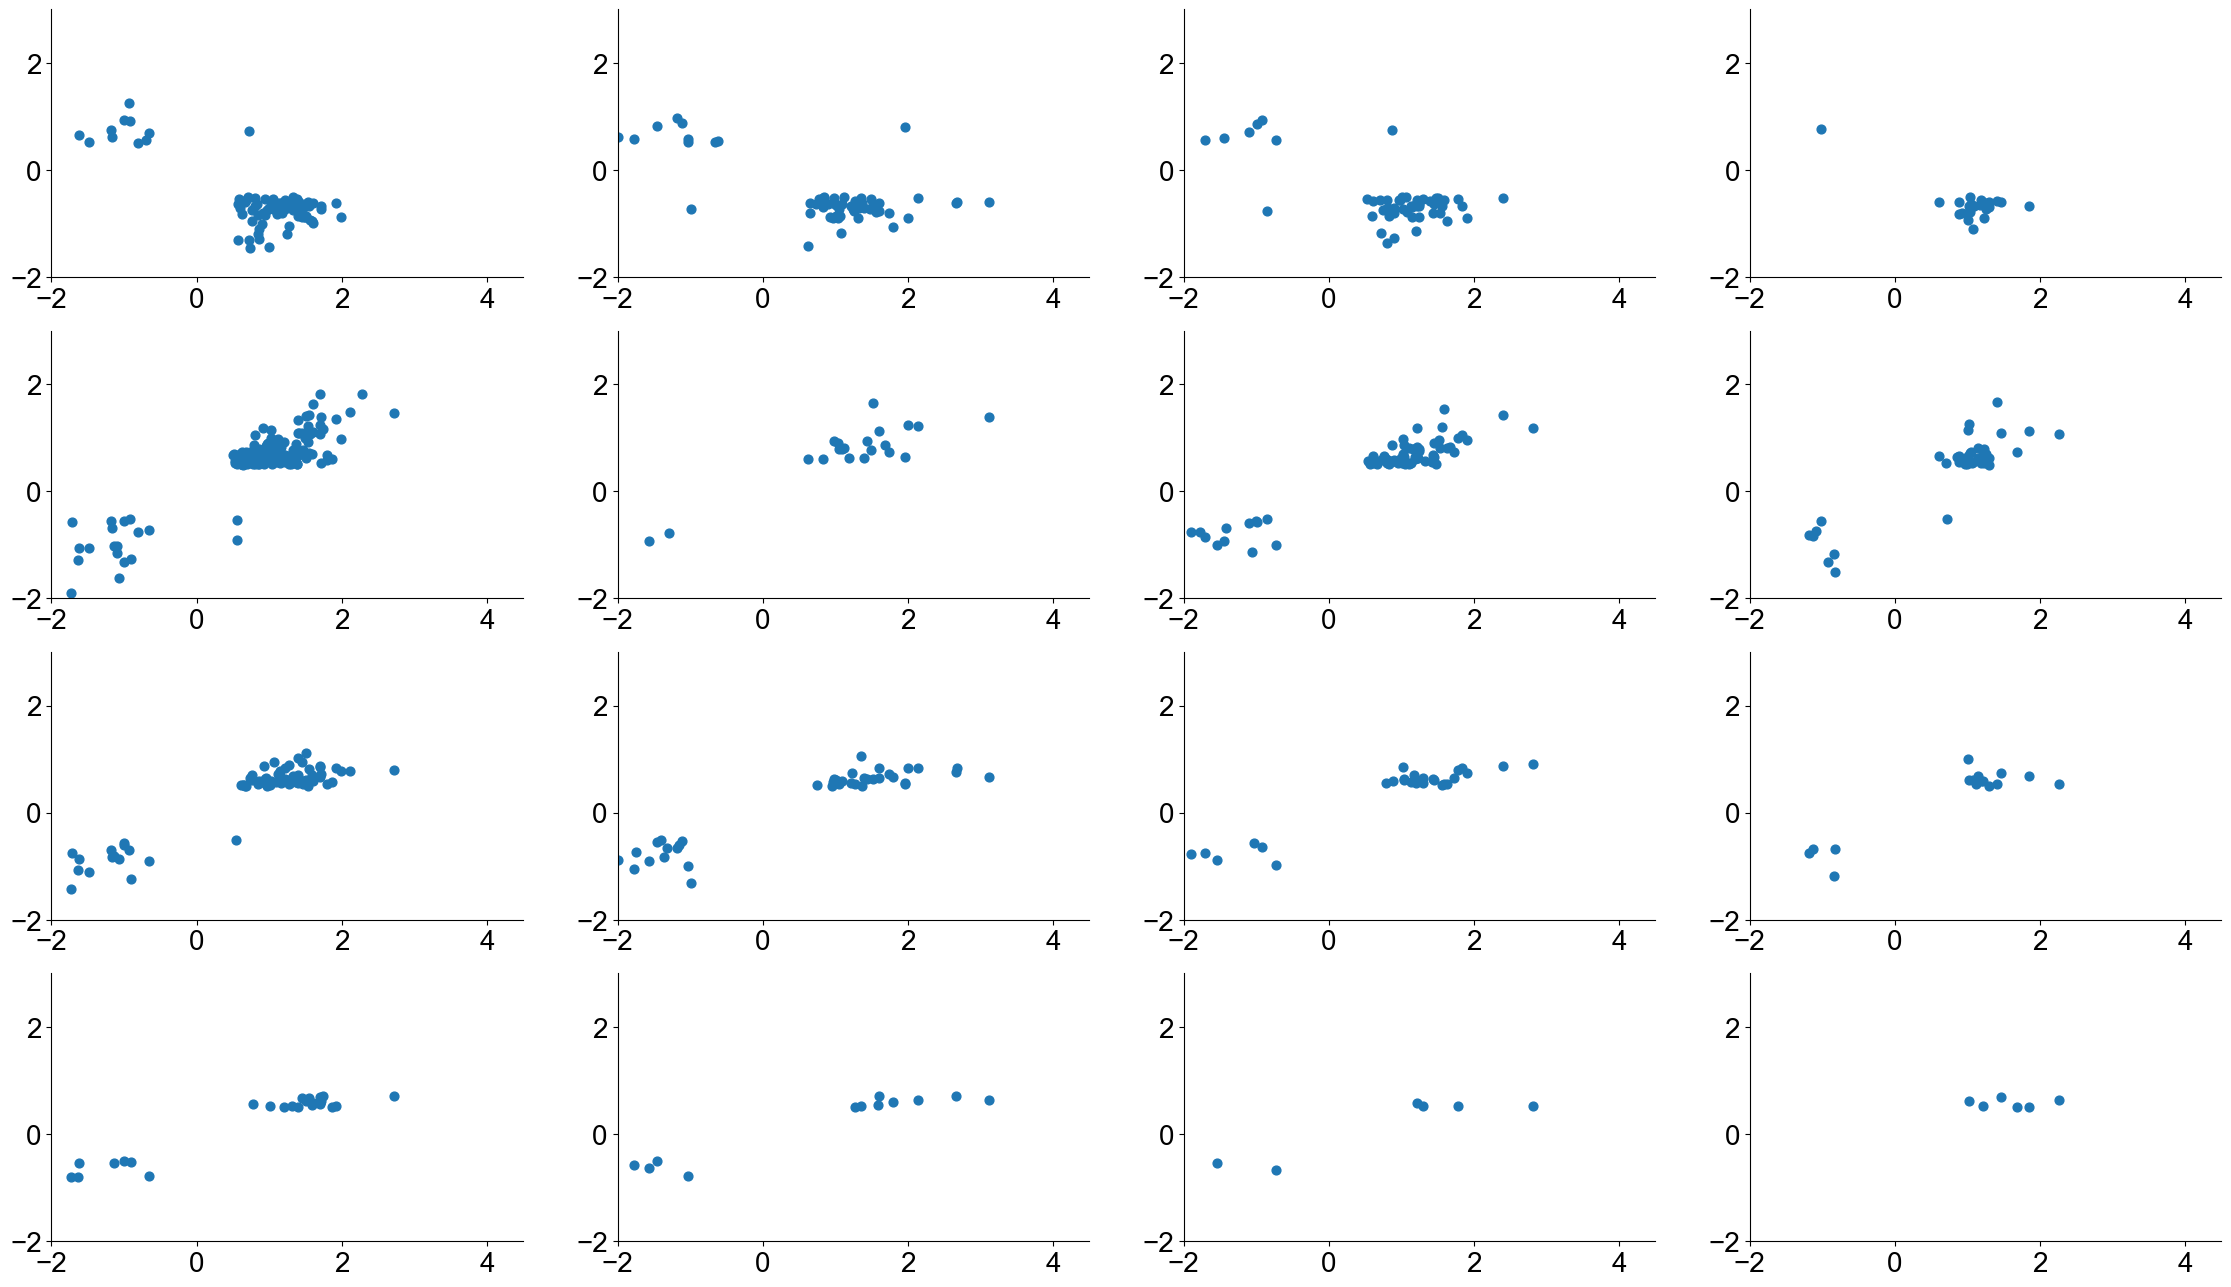

======> 7


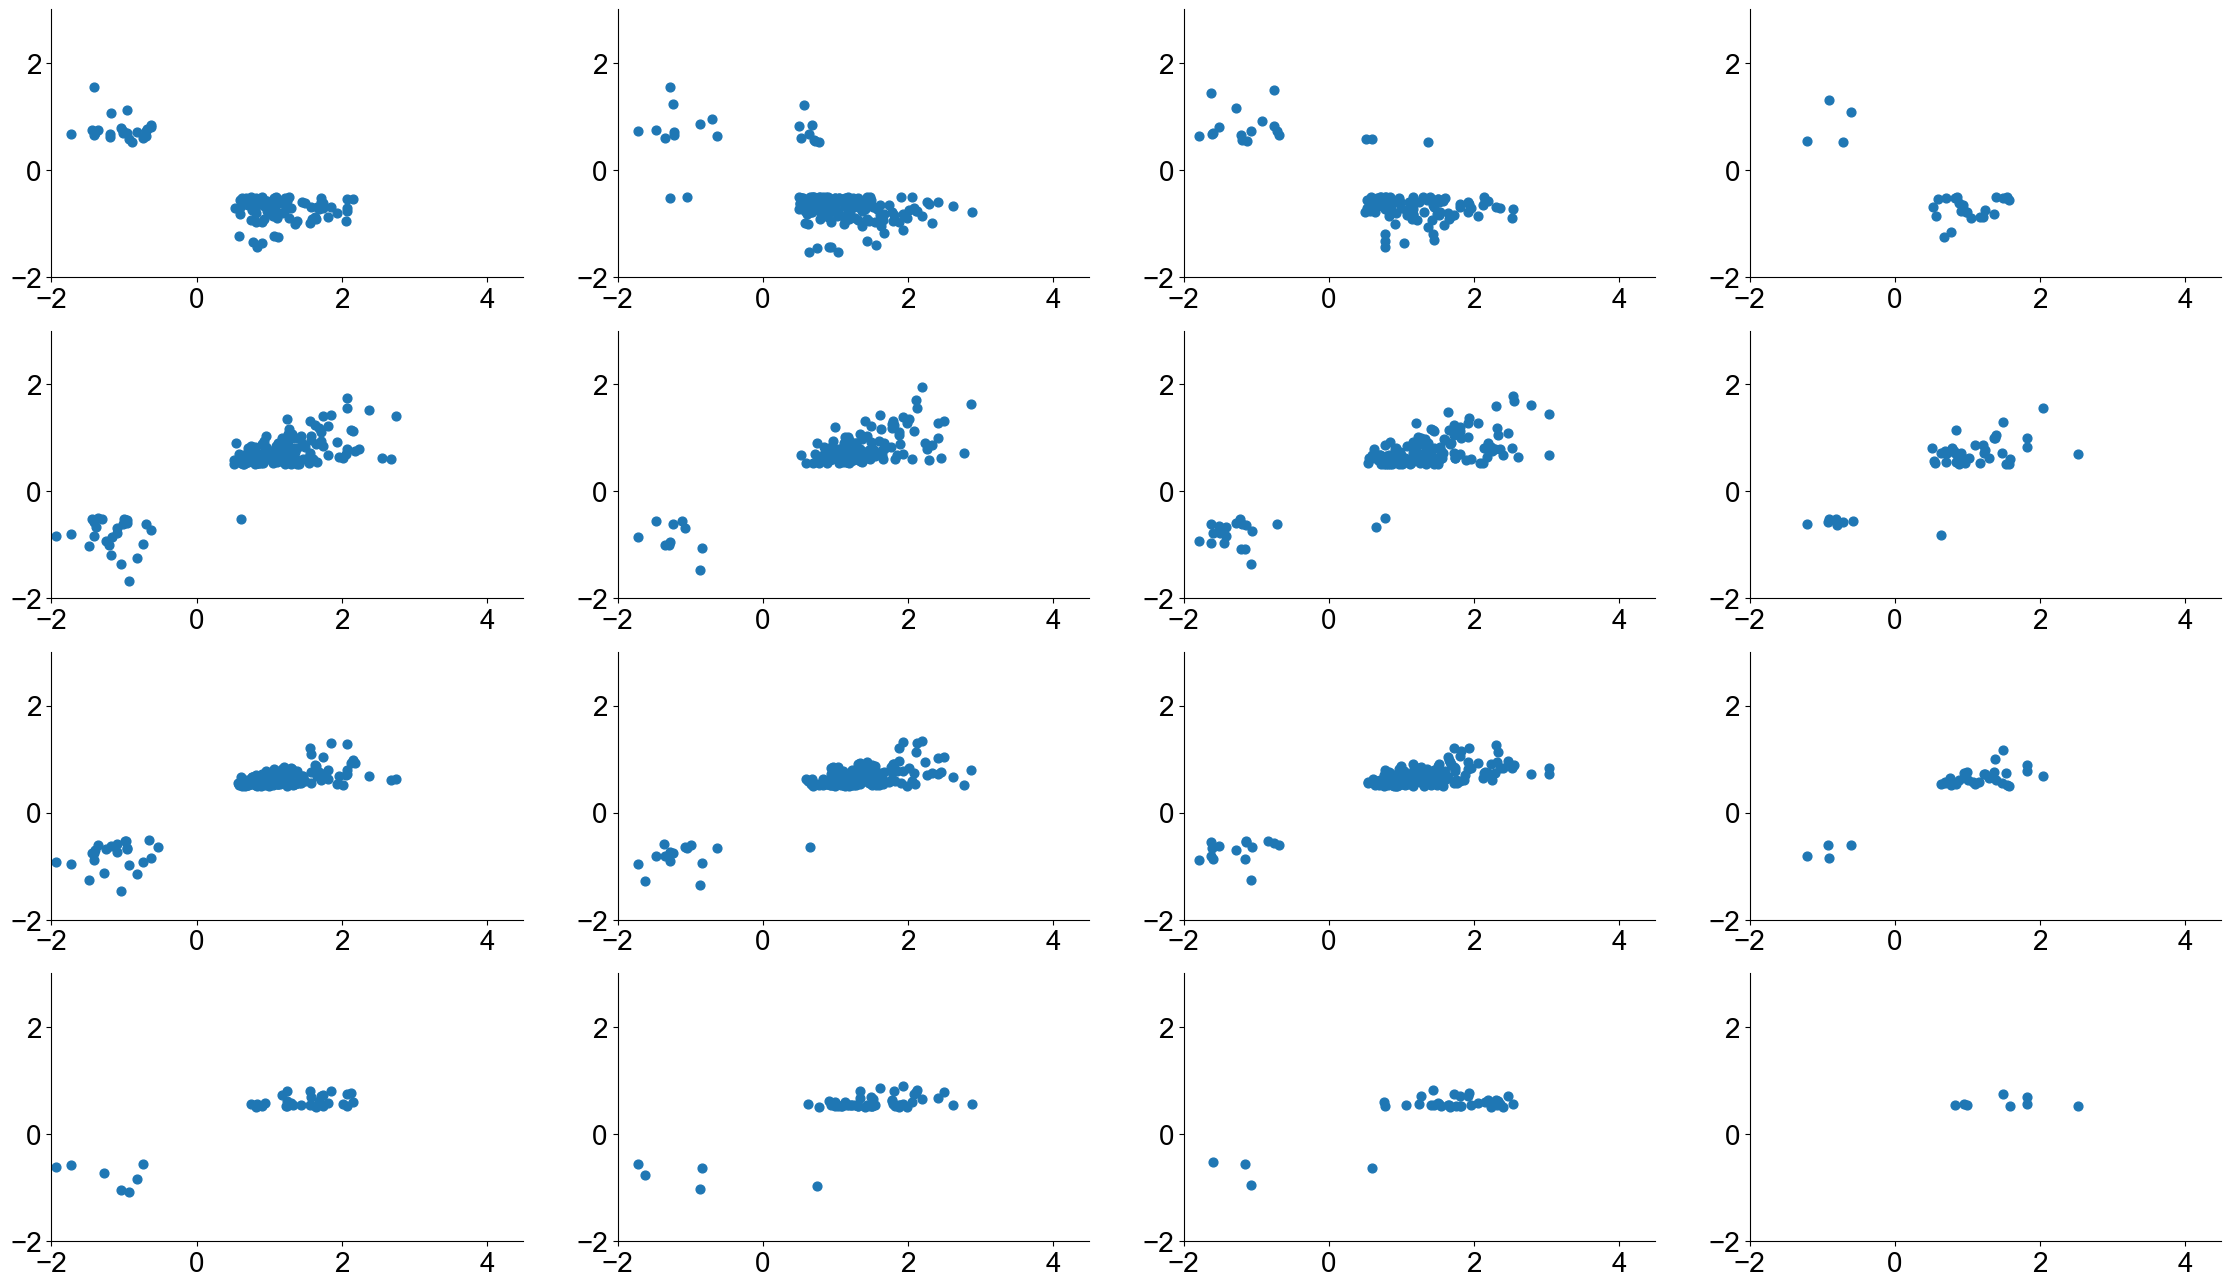

======> 8


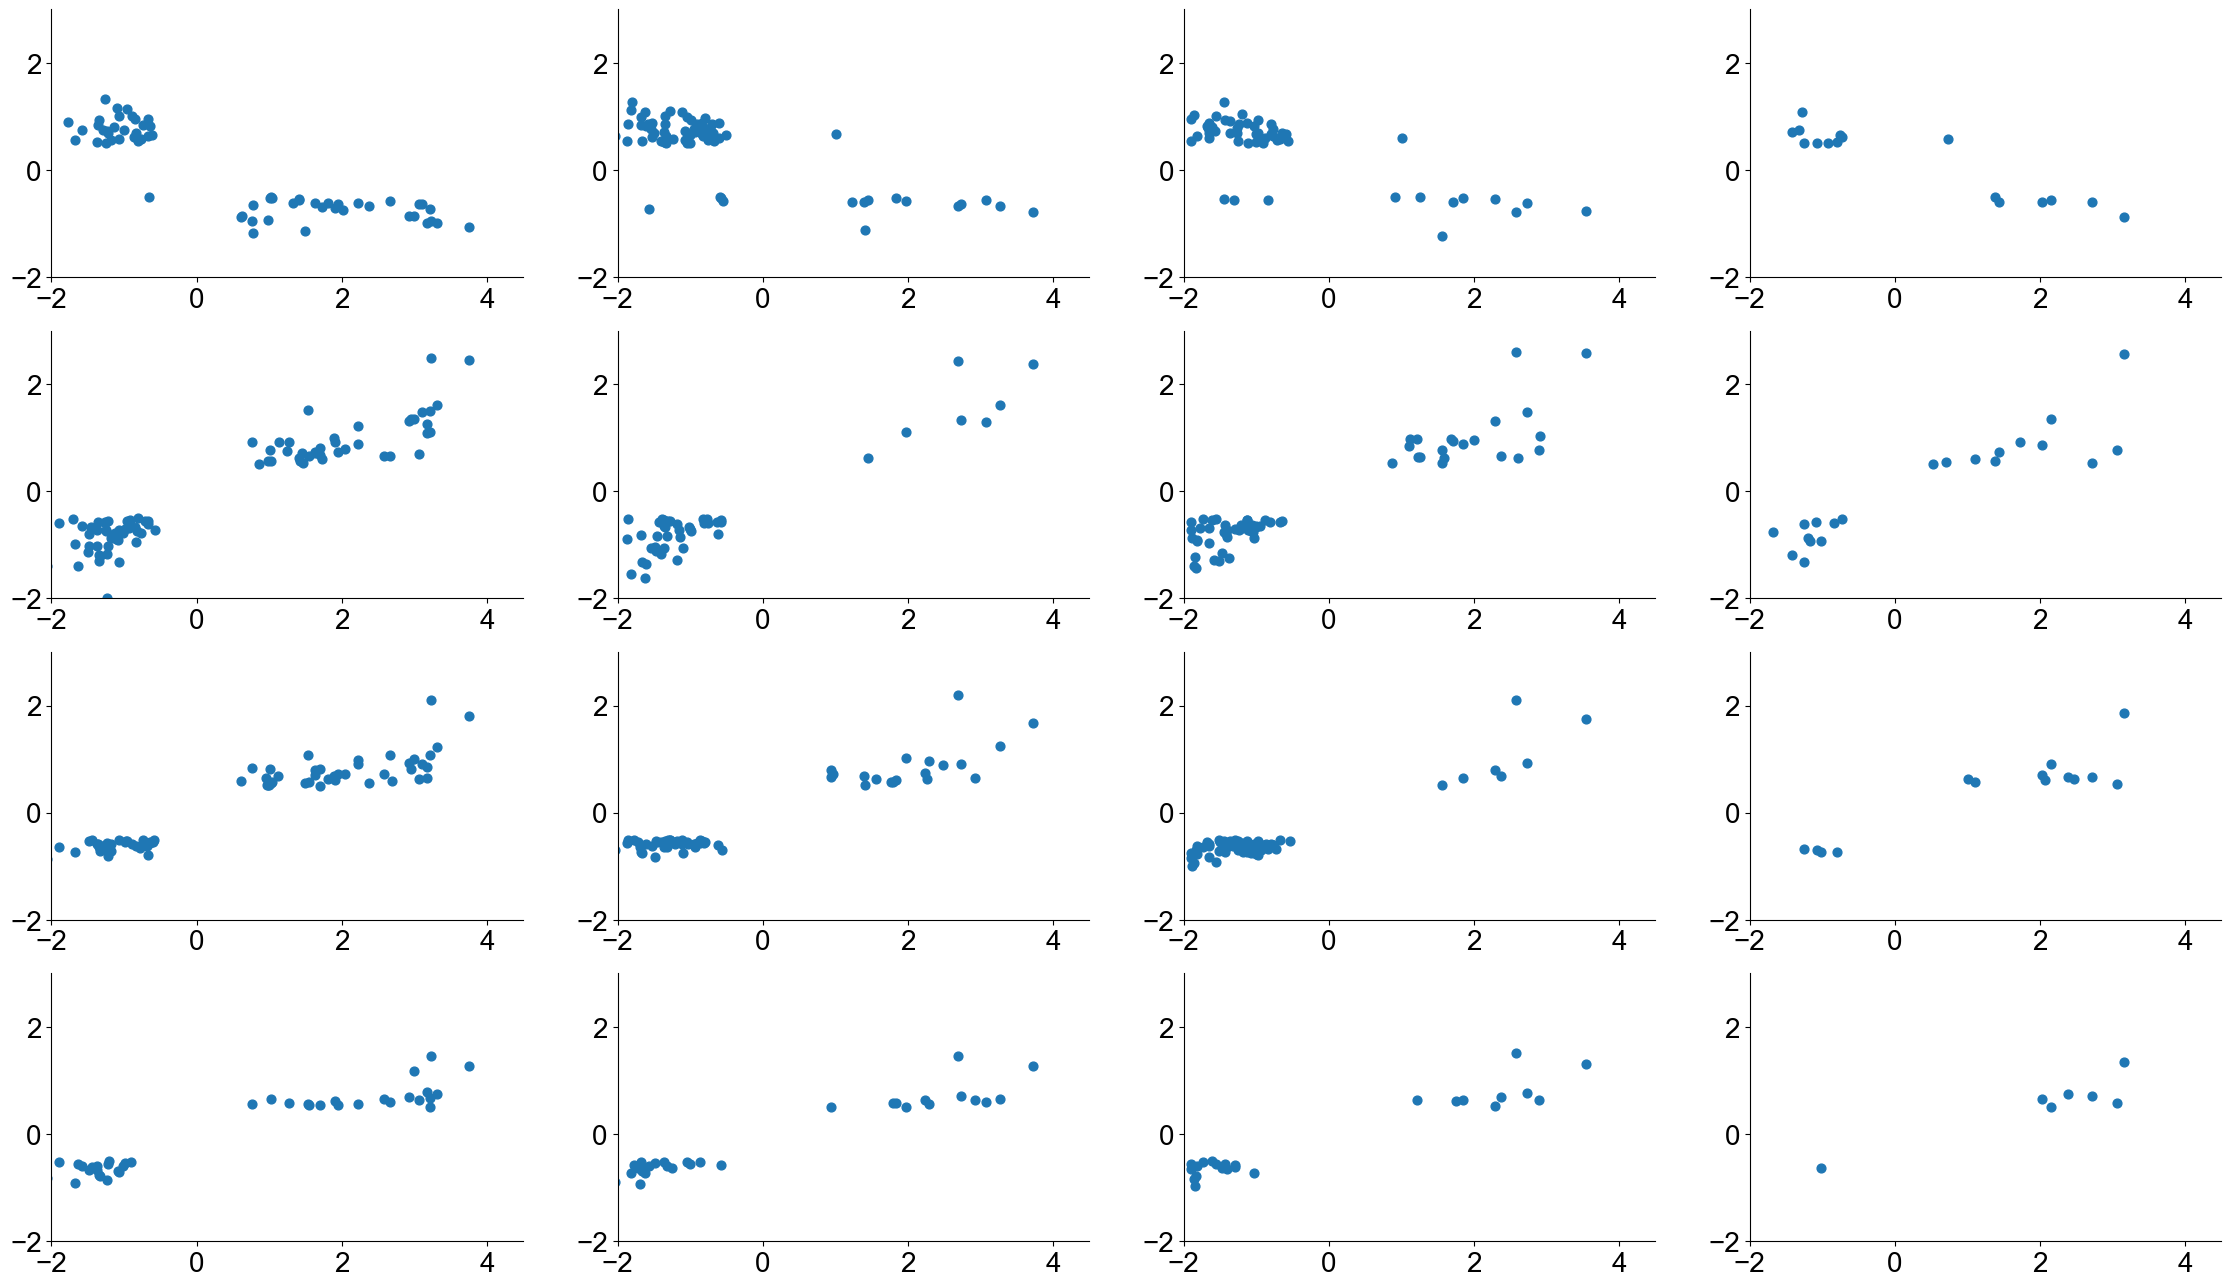

======> 9


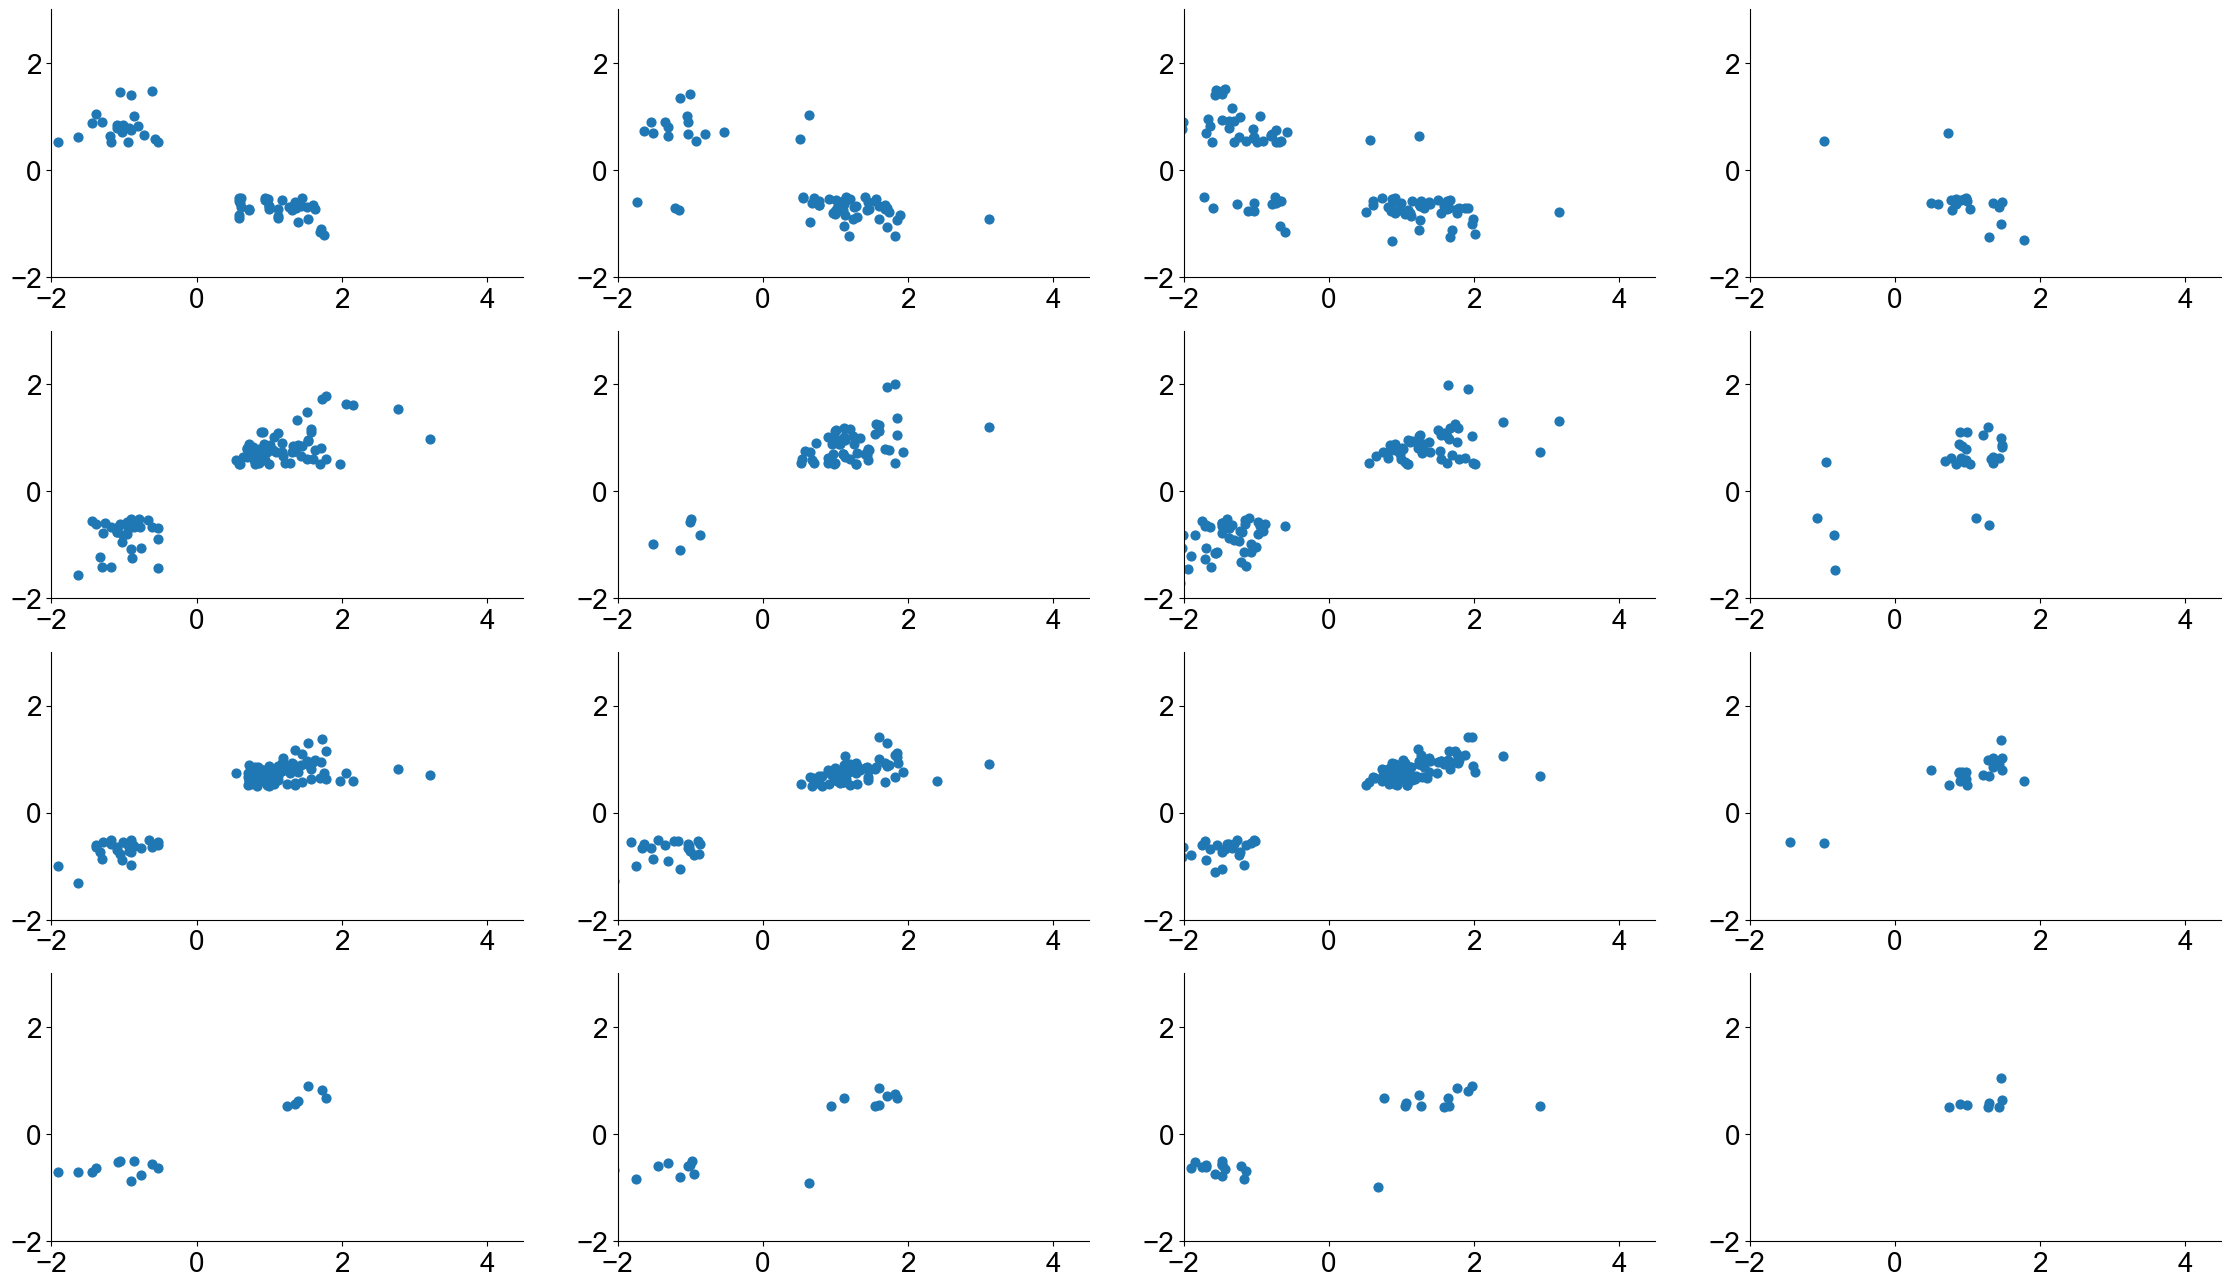

======> 10


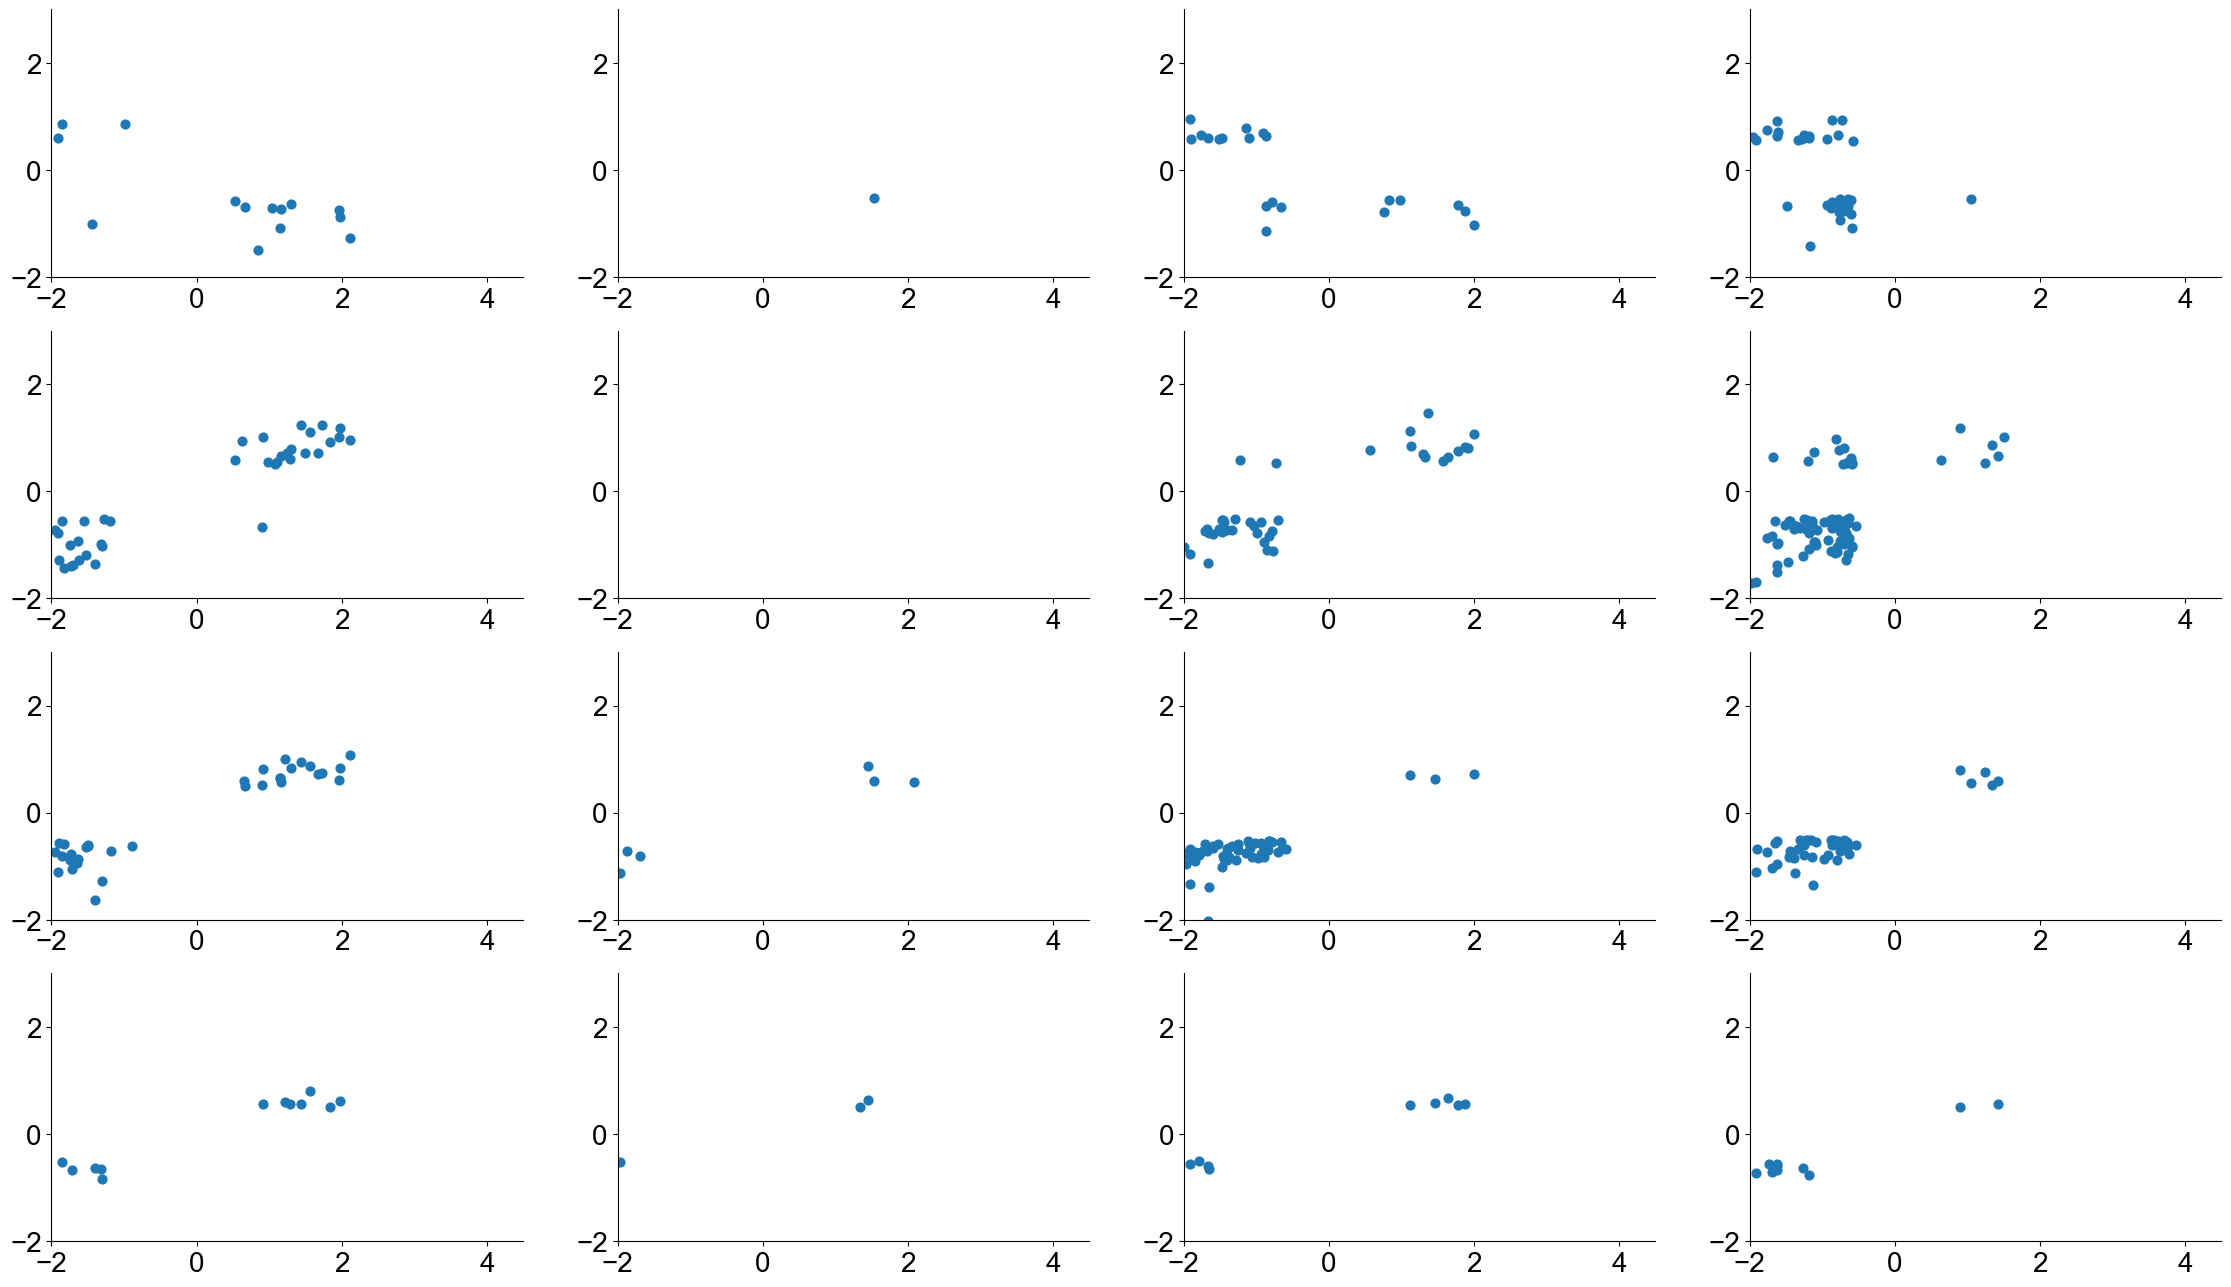

======> 11


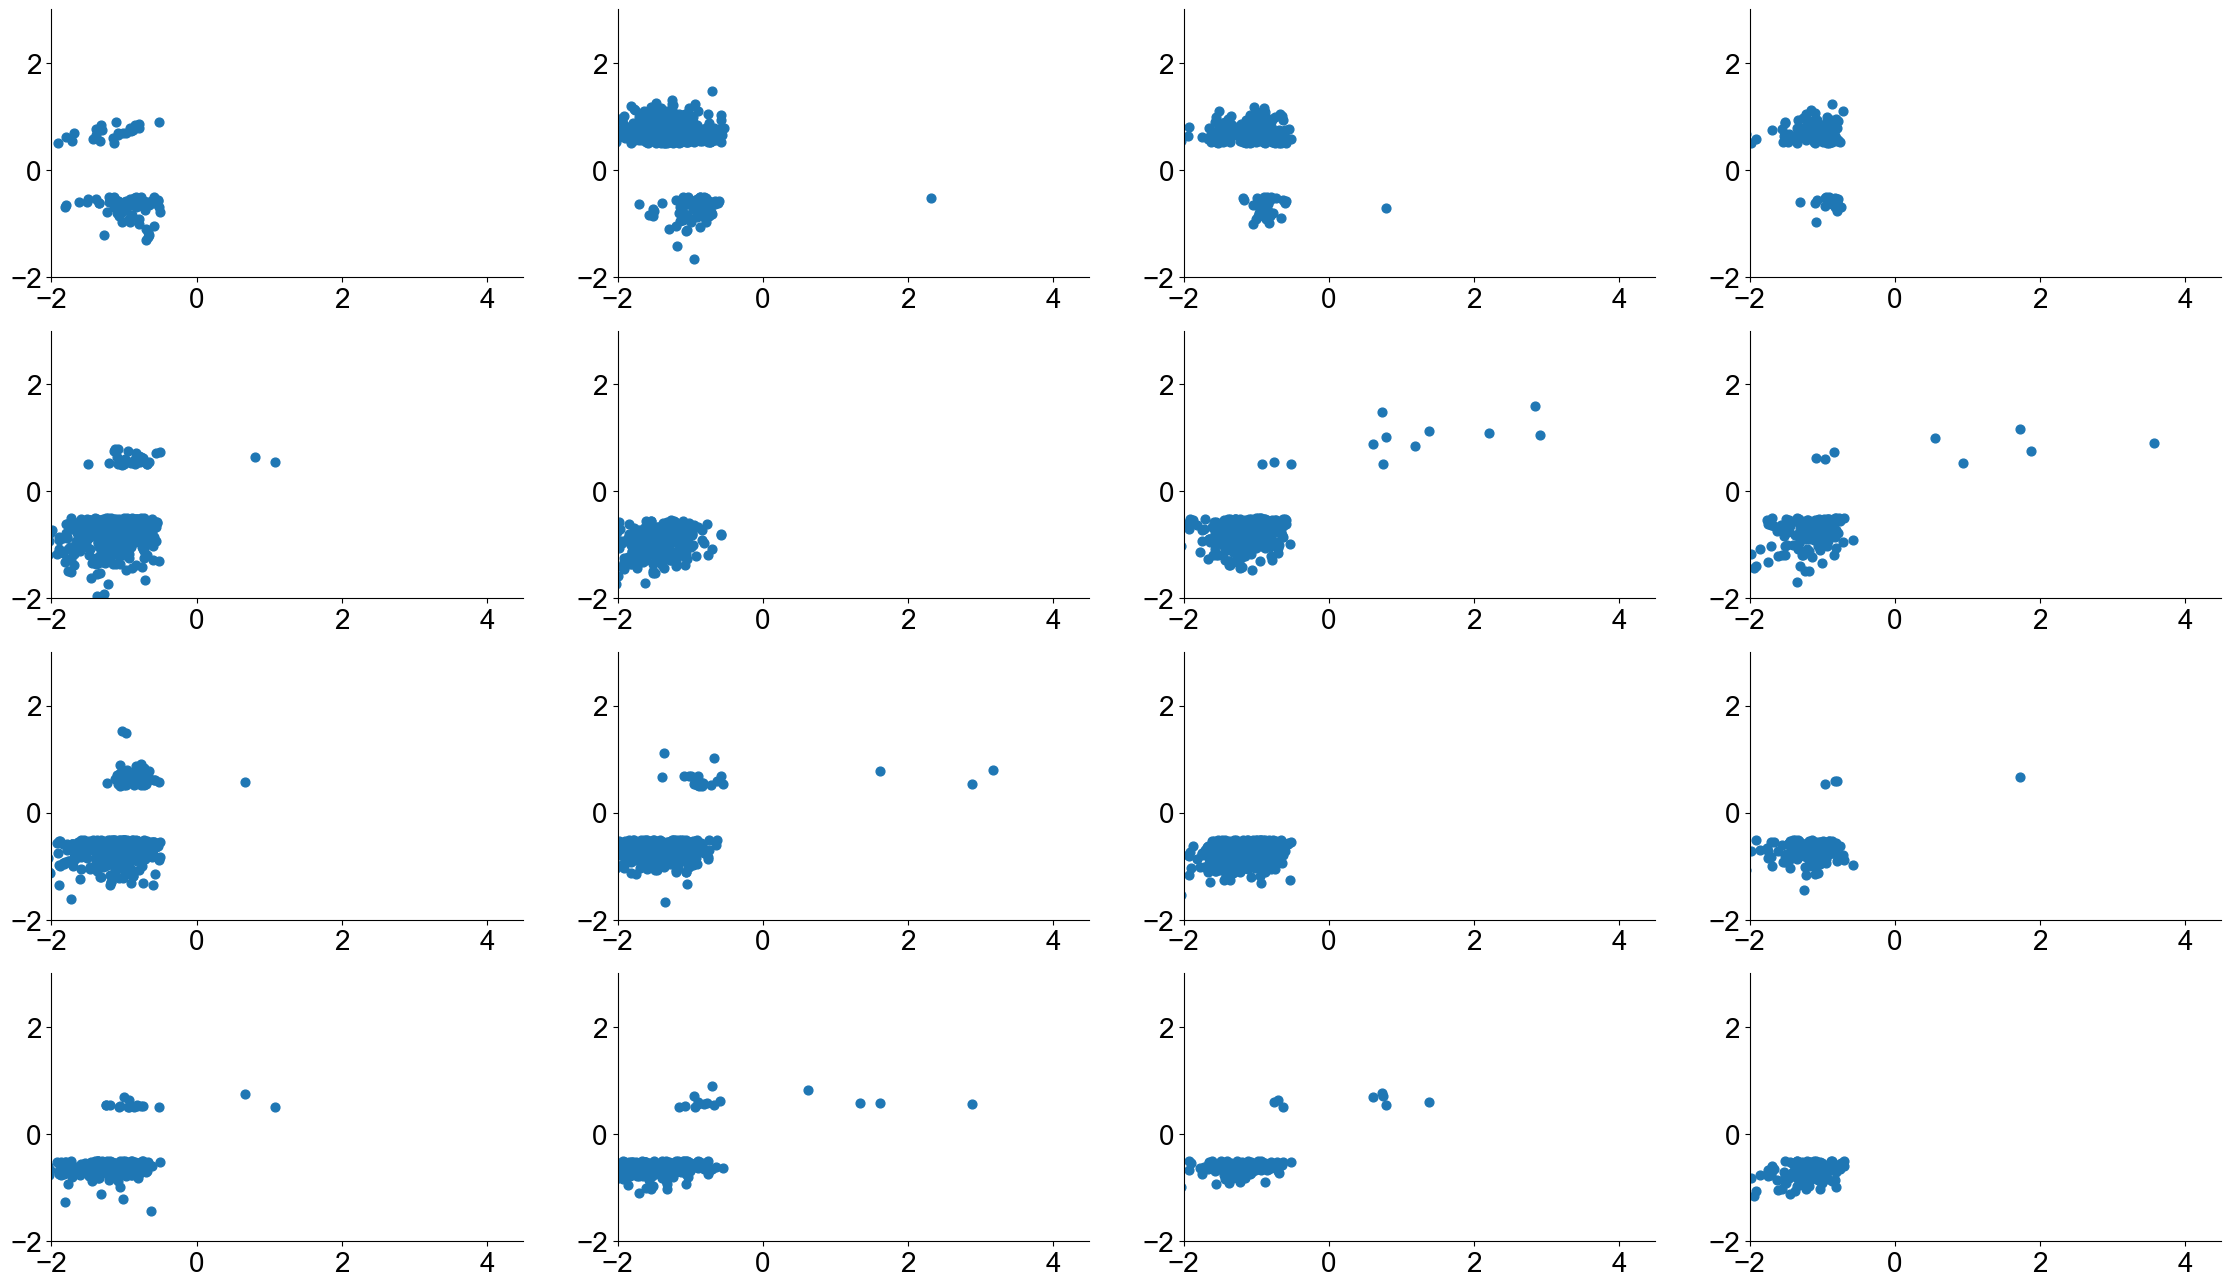

======> 12


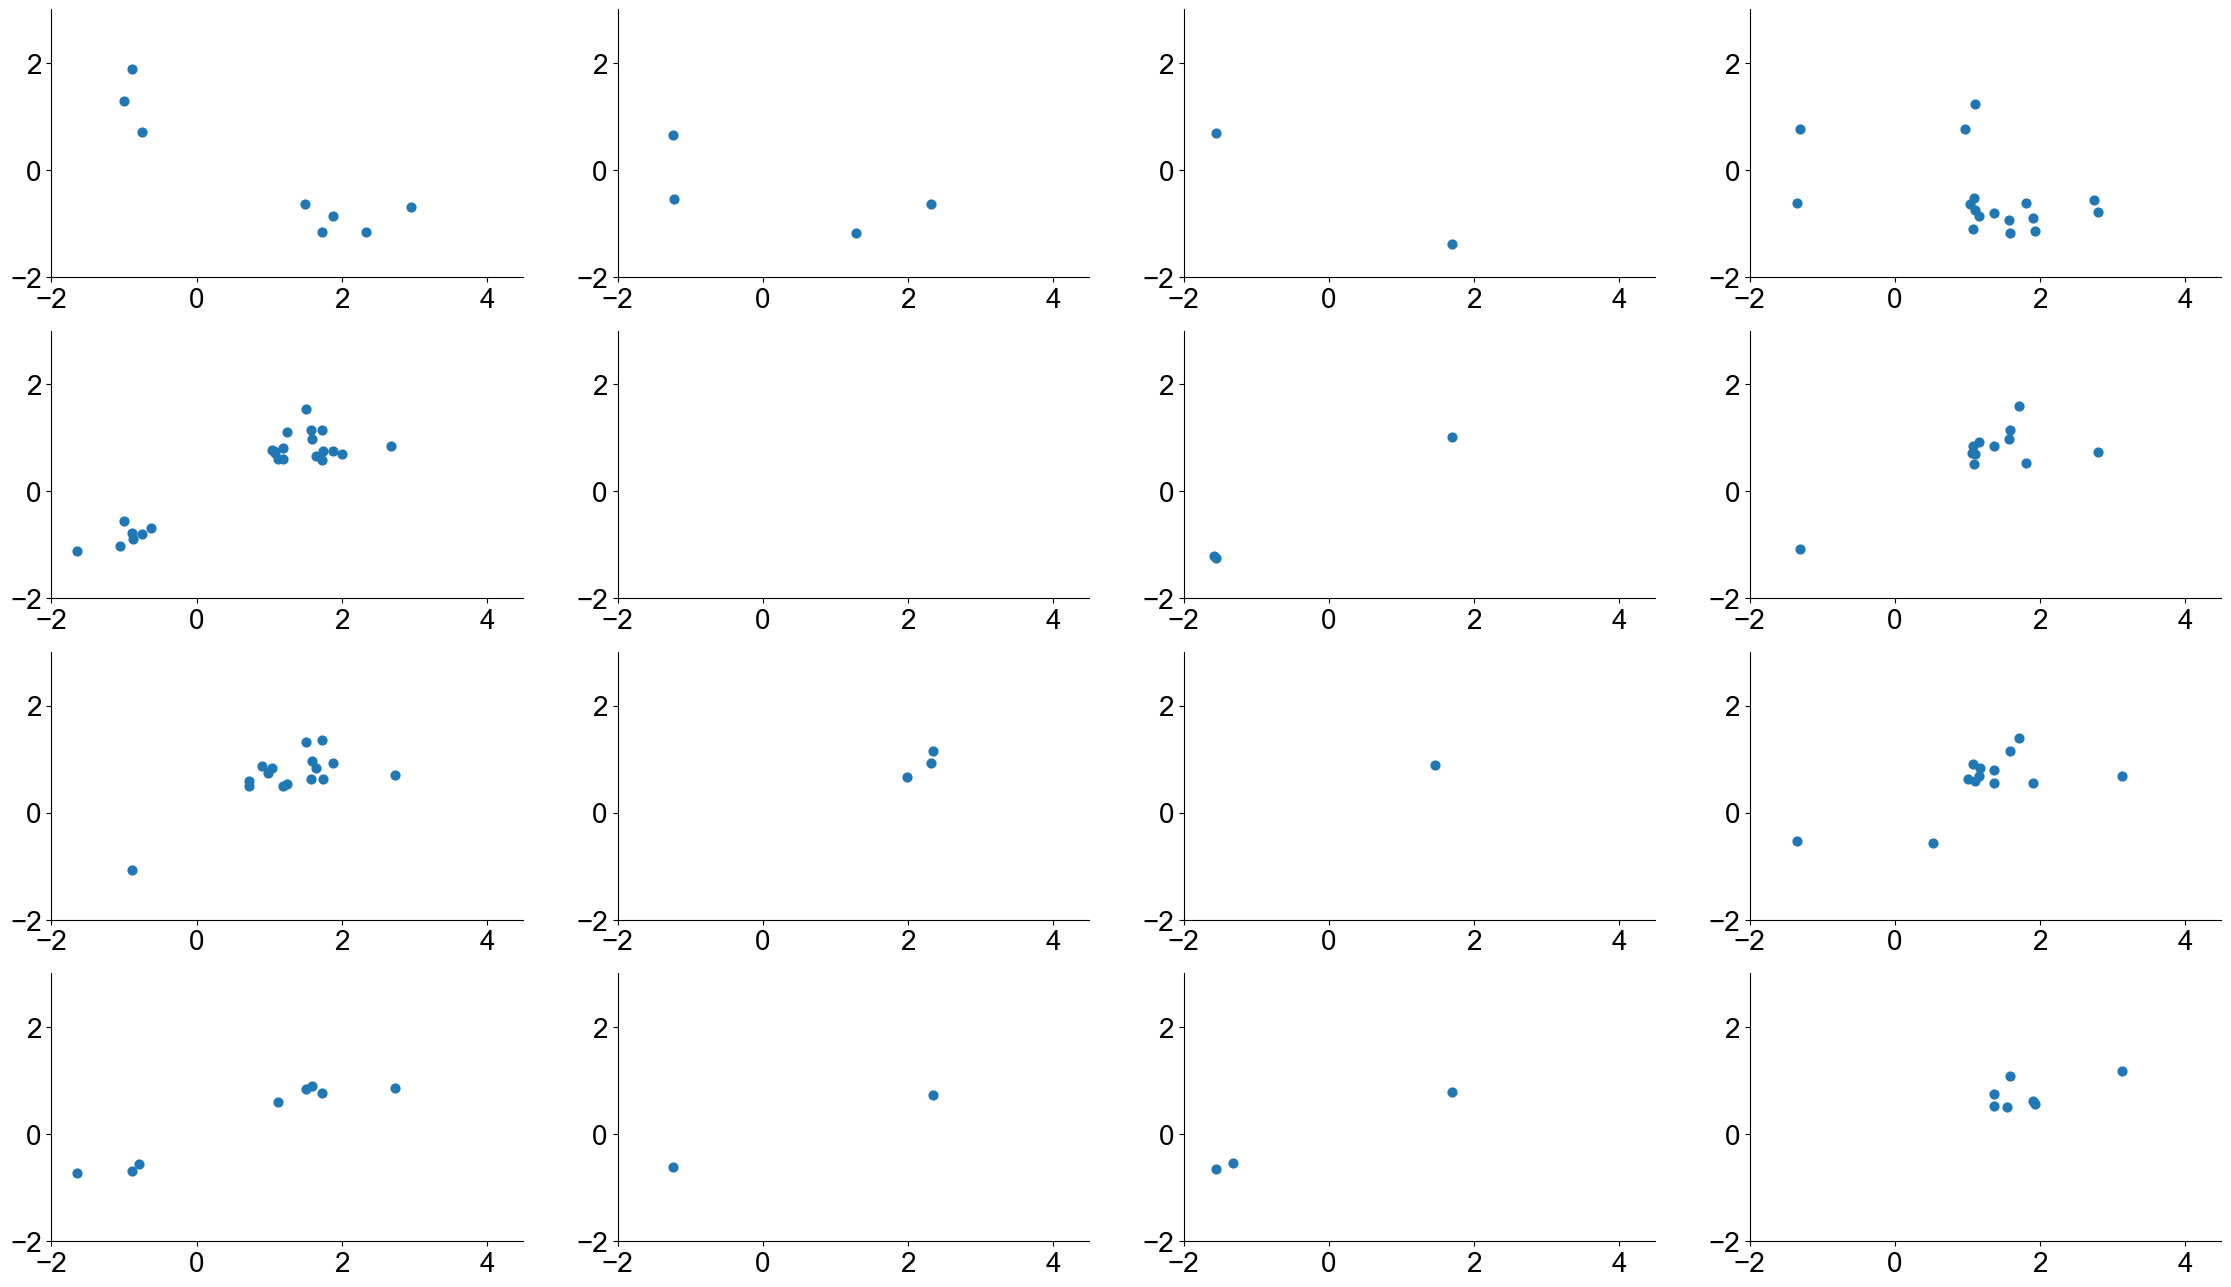

======> 13


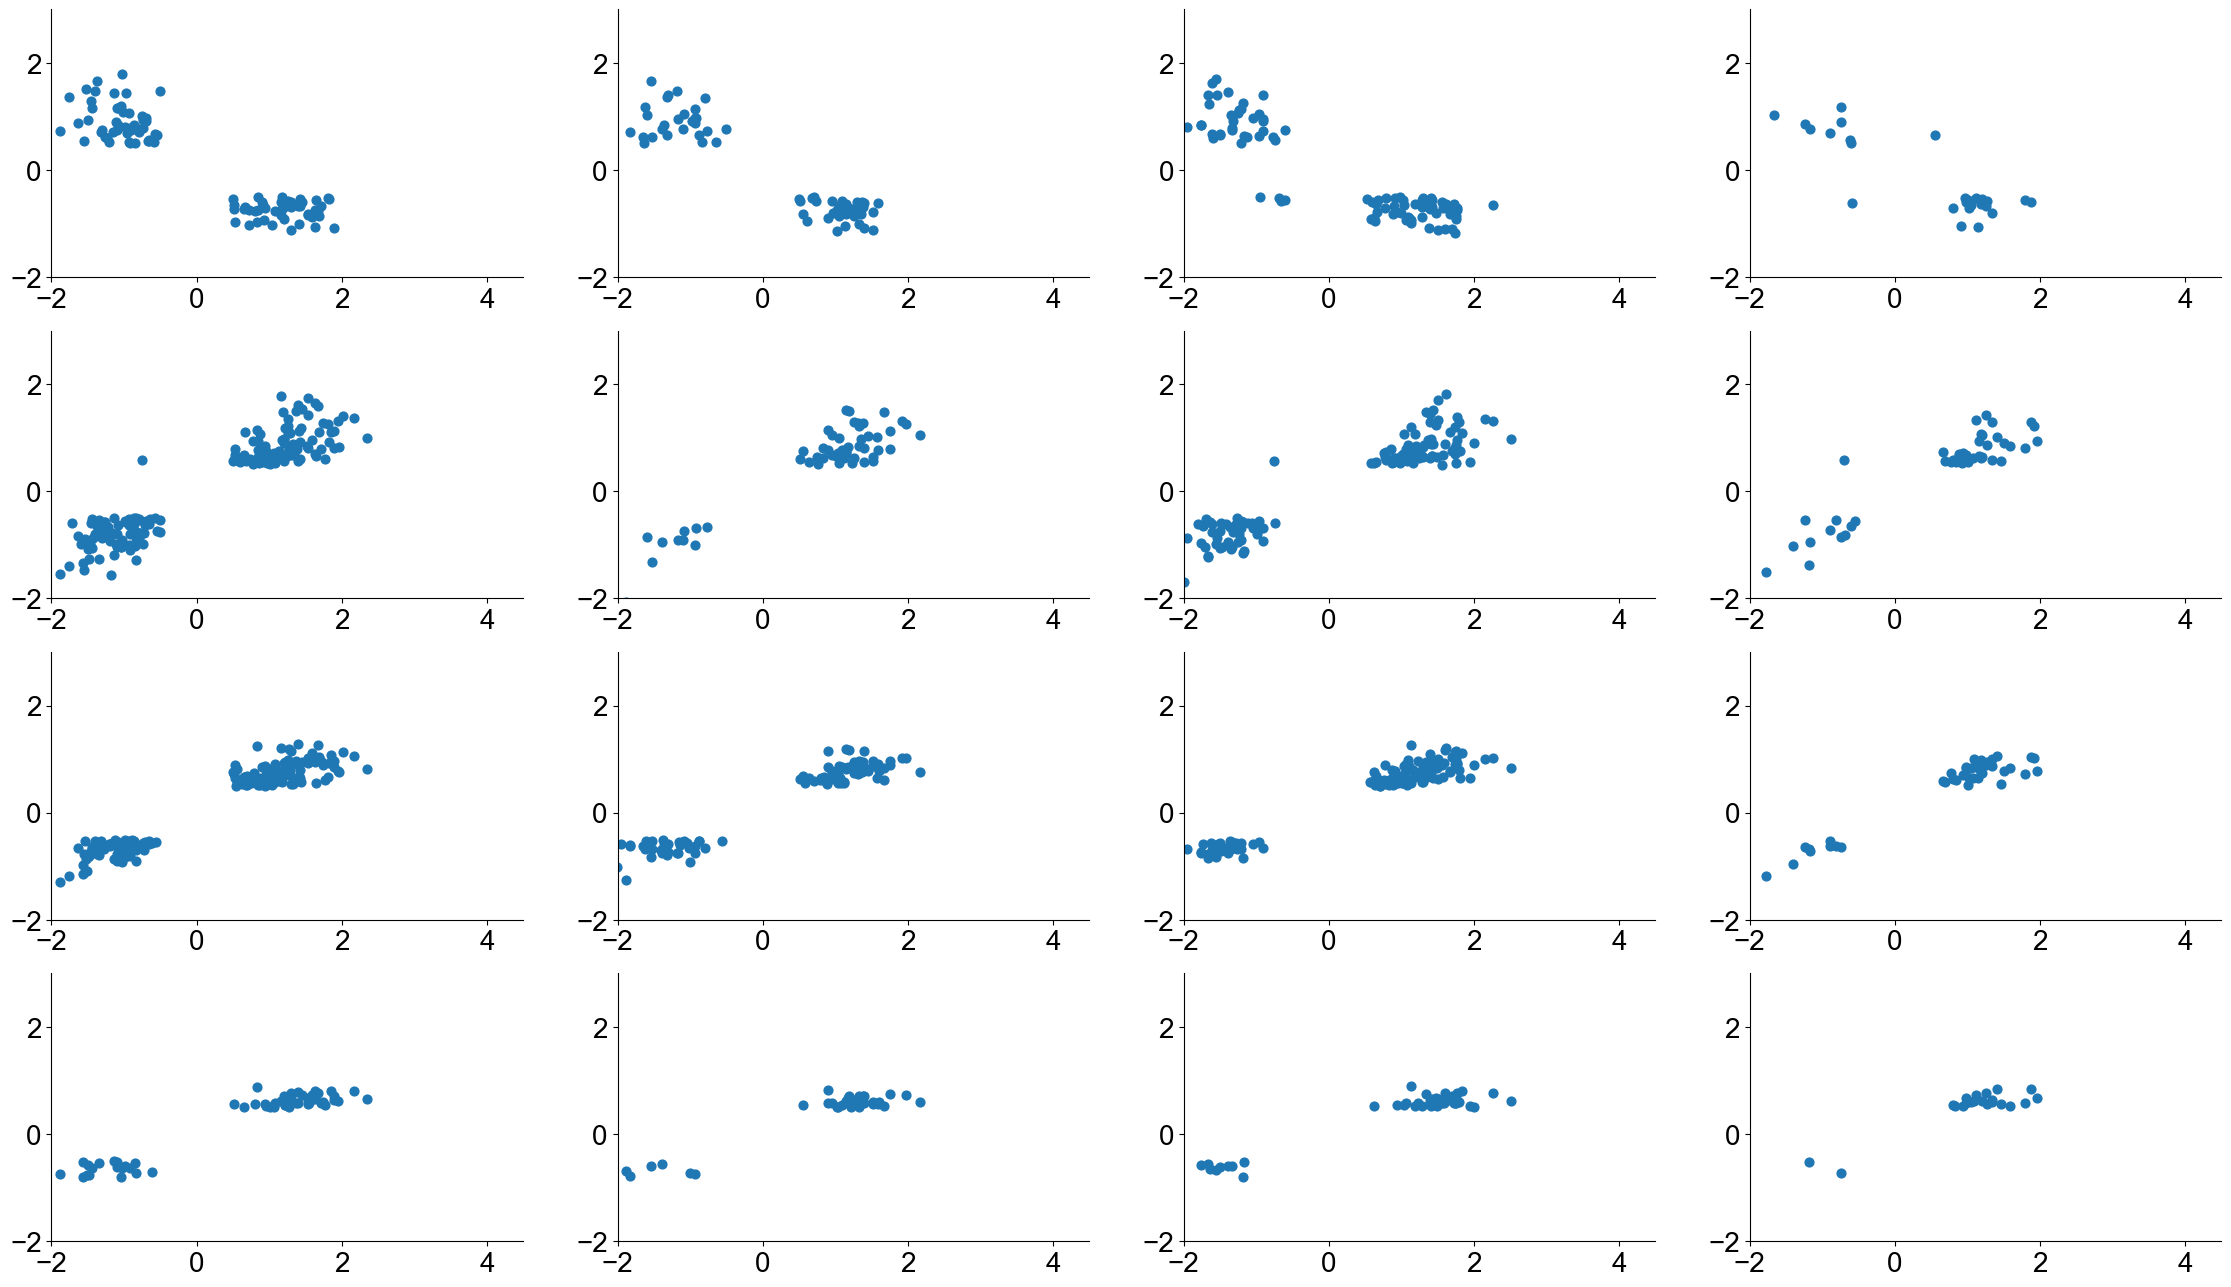

======> 14


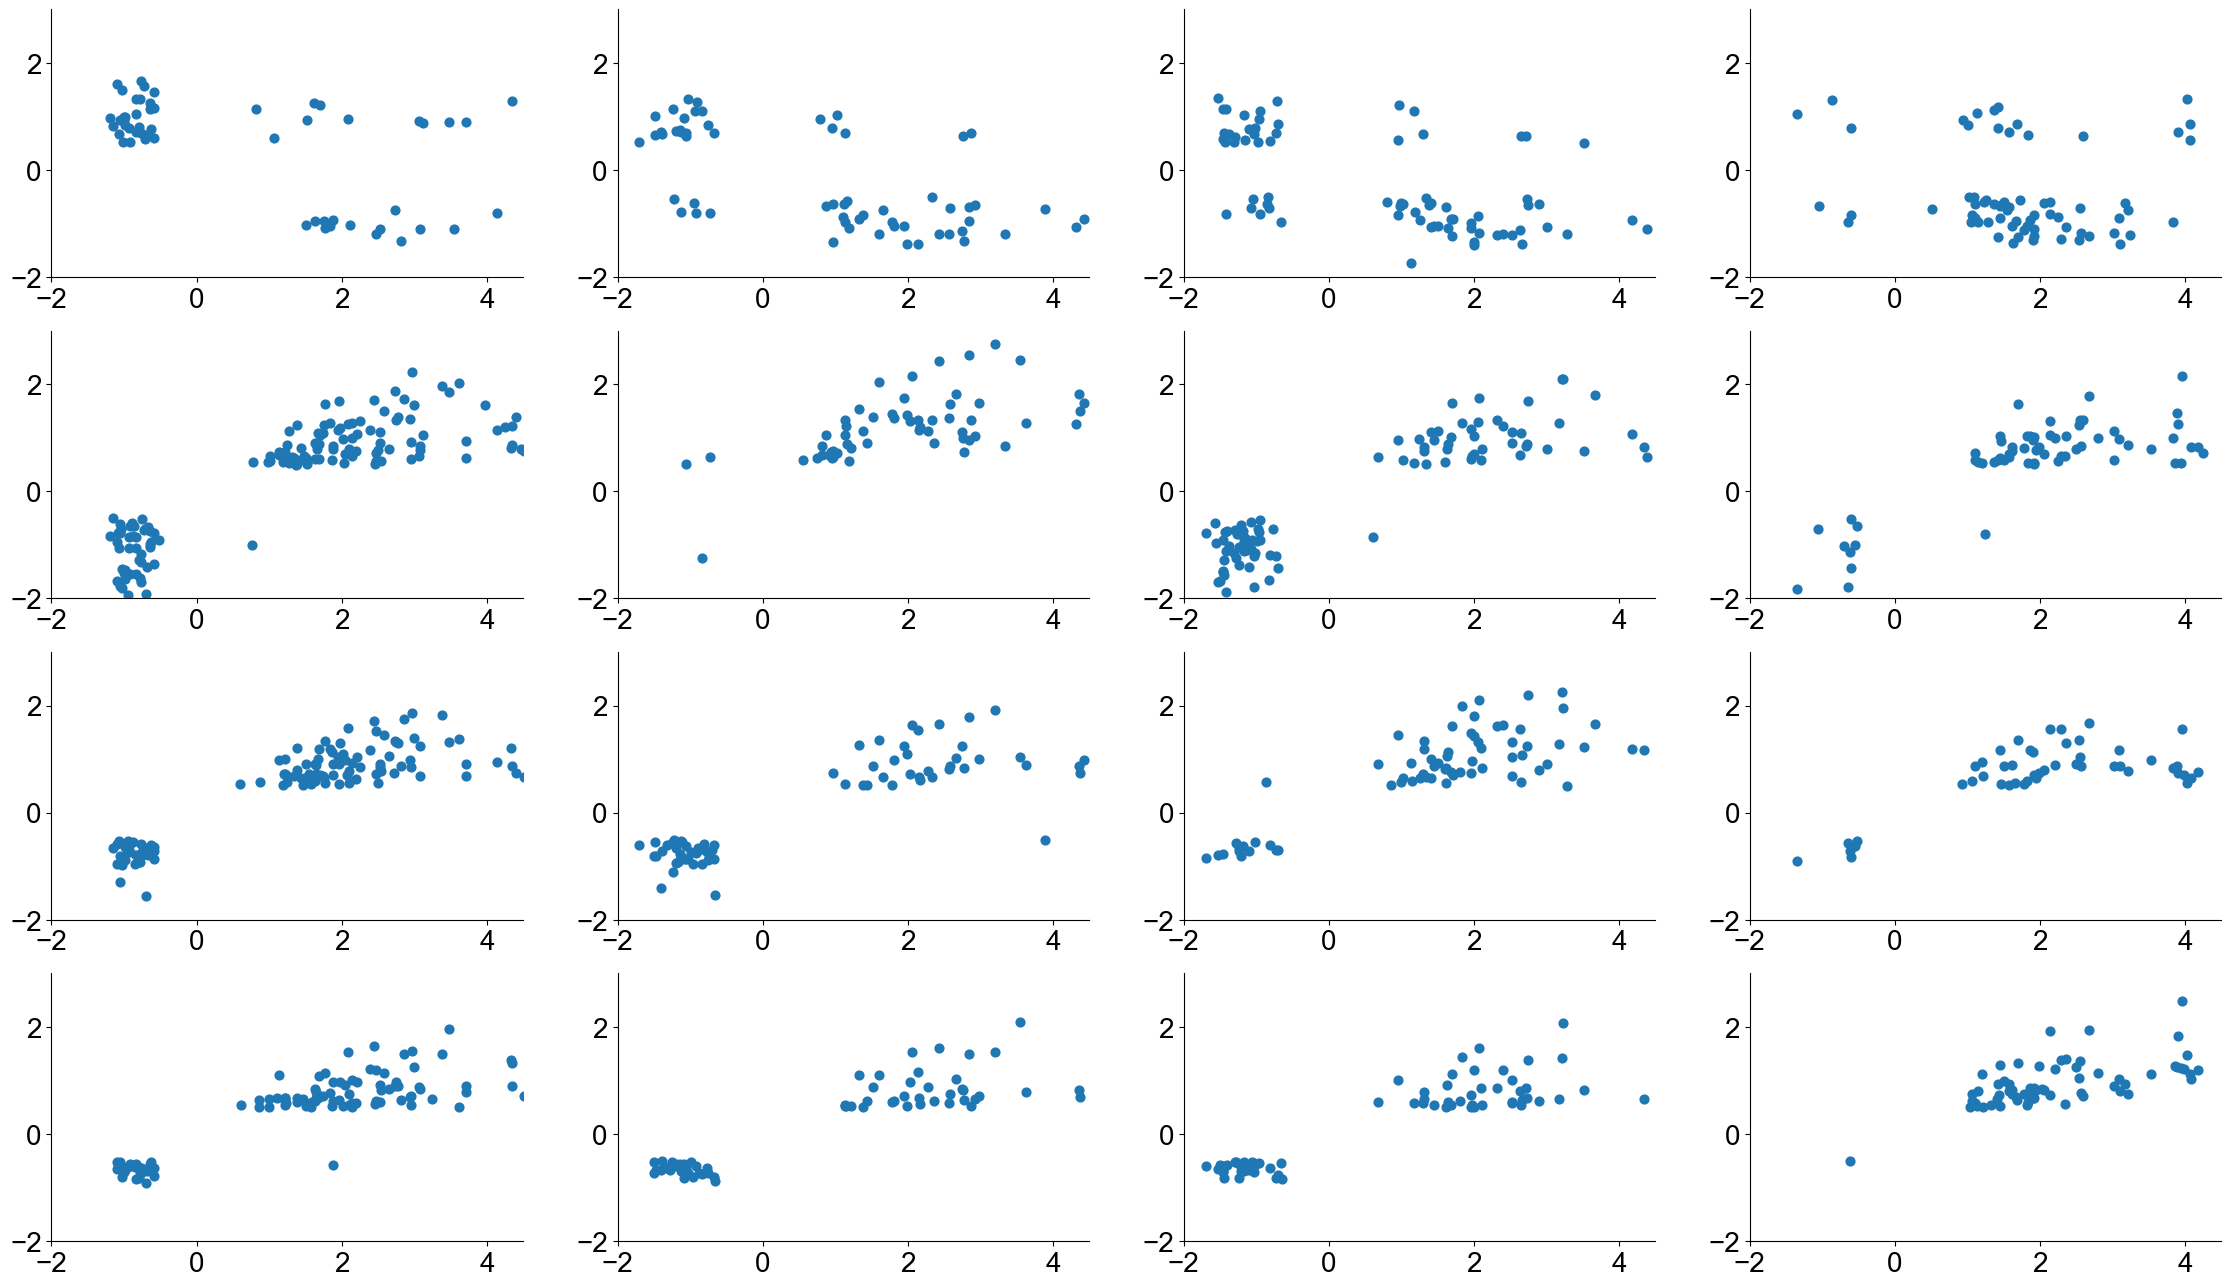

======> 15


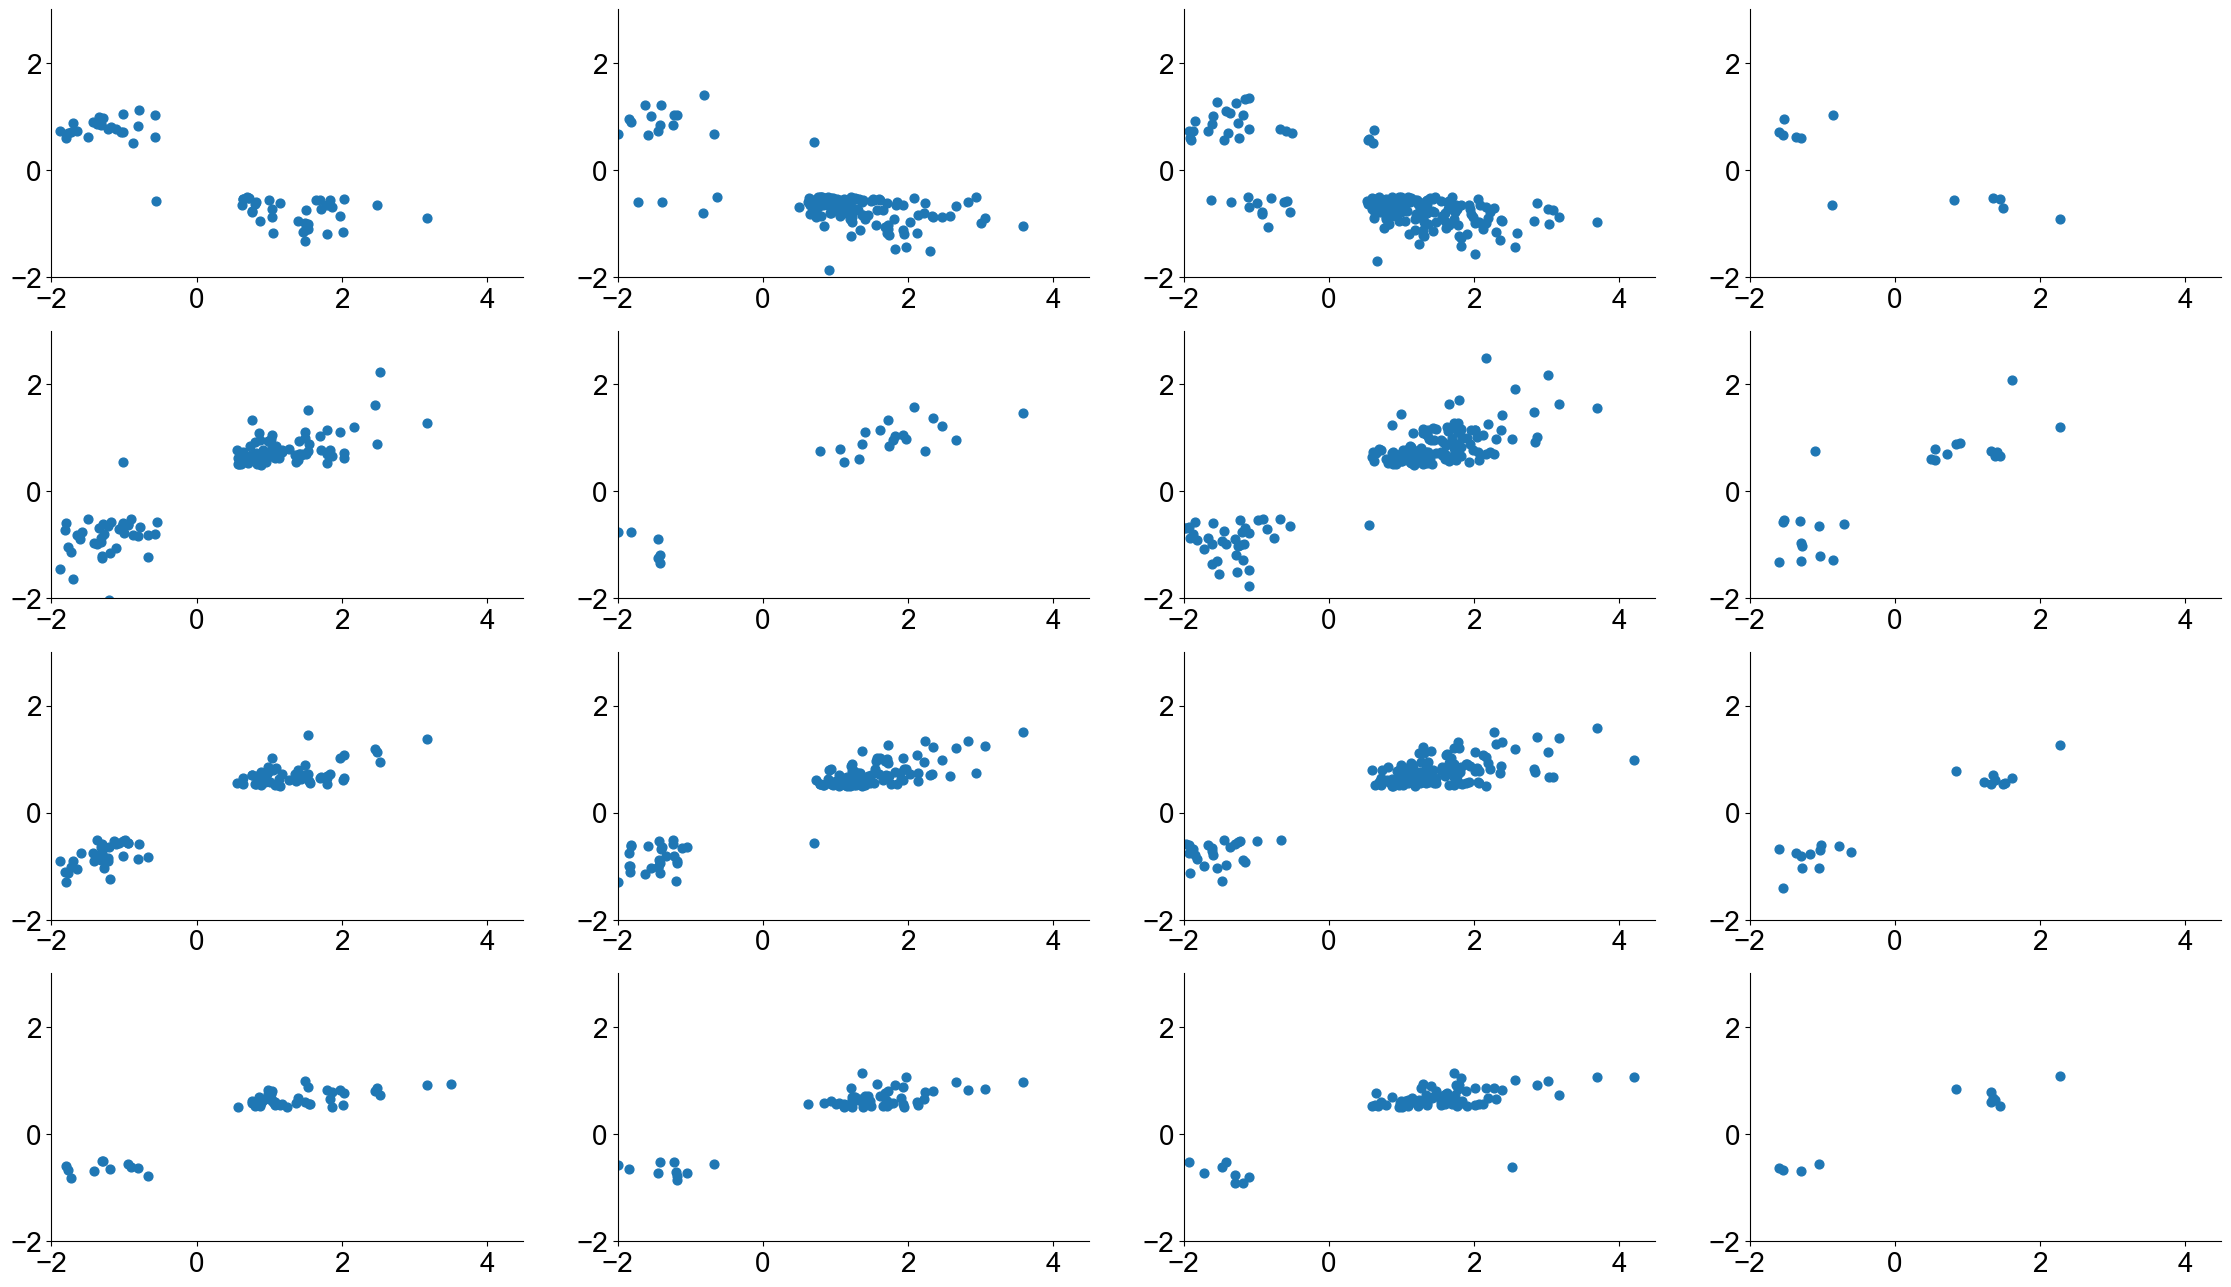

In [104]:
for clust in np.arange(1, 15+1, 1):
# for clust in [2]:
    clust = str(clust)
    adj_p_thr = 1e-5 
    print('======>', clust)
    rna_list    = [get_clust_marker(ad_mult_rna1, clust), get_clust_marker(ad_mult_rna2, clust), get_clust_marker(ad_mult_rna3, clust), get_clust_marker(ad_mult_rna4, clust)]
    k27me3_list = [get_clust_marker(ad_k27me3_gam, clust),  get_clust_marker(ad2_imp_k27me3_gam, clust), get_clust_marker(ad3_imp_k27me3_gam, clust),   get_clust_marker(ad4_imp_k27me3_gam, clust)]
    k4me3_list  = [get_clust_marker(ad1_imp_k4me3_gam, clust), get_clust_marker(ad_k4me3_gam, clust), get_clust_marker(ad3_imp_k4me3_gam, clust),       get_clust_marker(ad4_imp_k4me3_gam, clust)]
    k27ac_list  = [get_clust_marker(ad1_imp_k27ac_gam, clust), get_clust_marker(ad2_imp_k27ac_gam, clust),  get_clust_marker(ad_k27ac_gam, clust),      get_clust_marker(ad4_imp_k27ac_gam, clust)]
    atac_list   = [get_clust_marker(ad1_imp_atac_gam, clust), get_clust_marker(ad2_imp_atac_gam, clust), get_clust_marker(ad3_imp_atac_gam, clust),  get_clust_marker(ad_atac_gam, clust)]
    
    with plt.rc_context({'savefig.transparent': False, 
                         'font.size': 20, 'font.weight': 'regular', 'font.family': 'Arial',
                         'xtick.labelsize': 20,   # 放大 x 轴刻度
                         'ytick.labelsize': 20    # 放大 y 轴刻度
        }):  # Add any rc settings you want
        fig, axes = plt.subplots(4, 4, figsize=(7*4, 4*4))
        for ri, gam_list in enumerate([k27me3_list, k4me3_list, k27ac_list, atac_list]):
            # _, axes = plt.subplots(1, 4, figsize=(7*4, 4))
            for i, (d1, d2) in enumerate(zip(rna_list, gam_list)):
                _ = scatter_plot_impGAM_Scpy(d1, d2, adj_pval_thr=adj_p_thr, logfc_cutoff=0.5, ax=axes[ri][i])
                axes[ri][i].set_xlim(-2, 4.5)
                axes[ri][i].set_ylim(-2, 3)
                
        plt.show()

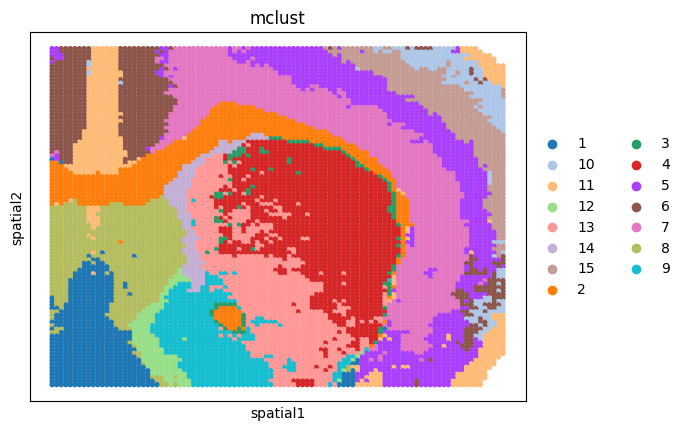

In [110]:
utls.plot_basis(ad_embs[0], 'spatial', ['mclust'], s=60)